# Panorama des données de courses

## À qui s'adresse ce document

Ce rapport s'adresse à **toute personne qui veut comprendre ce que contient la base** de
l'application : produit, analyse, métier ou simple curiosité. Il ne décrit ni la manière dont les
données sont collectées, ni le fonctionnement interne du serveur. La question est uniquement :
de quelles informations dispose-t-on, sur quelles courses, et avec quelle fiabilité ?

La période couverte va du **1er janvier 2025 au 31 août 2026**, soit vingt mois de calendrier
hippique sans interruption.

Les données proviennent du PMU et s'organisent en cinq familles, du général au particulier :

| Famille | Ce qu'elle décrit | Exemple |
| --- | --- | --- |
| **Journées de courses** | une date au calendrier hippique | le 14 juillet 2026 |
| **Réunions** | un rendez-vous sur un hippodrome, avec son contexte | R3 à Vincennes, ciel couvert, 12 °C |
| **Courses** | l'épreuve elle-même | Prix de Thoissey, trot monté, 2 200 m, 35 000 € |
| **Participants** | un cheval engagé, son profil et son résultat | n° 7, femelle de 4 ans, cote 12/1, 3ᵉ |
| **Rapports** | ce qu'un pari gagnant a rapporté | simple gagnant : 5,10 € pour 1 € |

Chaque section suit la même logique : les volumes, puis les distributions, puis **ce qu'il faut
en retenir**. La dernière partie recense les limites et les zones incomplètes, afin que personne
ne fonde une décision sur une information absente.

On peut lire le document d'un bout à l'autre, ou aller directement à la famille qui intéresse.
Dans tous les cas, la section 7 mérite un passage avant d'utiliser les données.

## Sommaire

1. [Vue d'ensemble](#vue-ensemble) — volumes, couverture du calendrier, journée type
2. [Les journées de courses](#journees) — rythme de la semaine et de l'année
3. [Les réunions](#reunions) — pays, hippodromes, météo et familles de courses
4. [Les courses](#courses) — disciplines, distances, dotations, horaires et terrain
5. [Les chevaux engagés](#chevaux) — profil, cotes, jockeys et place au départ
6. [Les rapports de paris](#rapports) — formules proposées, gains et stratégie naïve
7. [Ce qui est complet, ce qui ne l'est pas](#limites) — contrôles de cohérence et anomalies
8. [Le mot de la fin](#bilan) — synthèse et usages possibles

<a id="vue-ensemble"></a>
## 1. Vue d'ensemble

In [1]:
import sys
import warnings
from pathlib import Path

project_root = Path.cwd()
if not (project_root / "pmu").exists():
    project_root = project_root.parent
sys.path.append(str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import design_system as ds
from pmu.types.types import ProgrammeIdentifier
from pmu.utils import programme_date_to_date, programme_dates_between_dates

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)

THEME = ds.apply_theme("light")

start_date = ProgrammeIdentifier("01012025")
end_date = ProgrammeIdentifier("31082026")
jours_attendus = programme_dates_between_dates(start_date, end_date)
debut = pd.Timestamp(programme_date_to_date(str(start_date)))
fin = pd.Timestamp(programme_date_to_date(str(end_date)))
calendrier_complet = pd.date_range(debut, fin, freq="D")

In [2]:
JOURS = ["Lundi", "Mardi", "Mercredi", "Jeudi", "Vendredi", "Samedi", "Dimanche"]
MOIS = ["Jan", "Fév", "Mar", "Avr", "Mai", "Juin", "Juil", "Août", "Sep", "Oct", "Nov", "Déc"]
ESPACE = "\u202f"


def nombre(valeur, decimales=0, unite=""):
    """Met en forme un nombre à la française : 12 345,6."""
    if pd.isna(valeur):
        return "—"
    texte = f"{valeur:,.{decimales}f}".replace(",", ESPACE).replace(".", ",")
    return f"{texte}{unite}"


def tableau(frame, titre=None, formats=None, barres=None, gradient=None, precision=0, index=True):
    """Tableau mis en forme avec les couleurs et la typographie du design system."""
    styler = frame.style.set_table_styles(ds.table_css("light"))
    if titre:
        styler = styler.set_caption(titre)
    if formats:
        styler = styler.format(formats, na_rep="—")
    else:
        styler = styler.format(precision=precision, thousands=ESPACE, decimal=",", na_rep="—")
    if barres:
        styler = styler.bar(subset=barres, color=THEME["chart_3"], align="left", height=62, width=96)
    if gradient:
        styler = styler.background_gradient(cmap=ds.sequential_cmap("light"), subset=gradient)
    if not index:
        styler = styler.hide(axis="index")
    return styler


def chiffres_cles(valeurs: dict, titre: str):
    """Petit tableau « indicateur / valeur » pour ouvrir une section."""
    frame = pd.DataFrame({"": list(valeurs.values())}, index=list(valeurs.keys()))
    return tableau(frame, titre, formats={"": "{}"})


def disponibilite(frame, libelles: dict, titre: str):
    """Part des enregistrements pour lesquels chaque information est renseignée."""
    part = (frame[list(libelles)].notna().mean() * 100).rename(index=libelles)
    part = part.sort_values(ascending=False).to_frame("Renseigné (%)")
    return tableau(part, titre, formats={"Renseigné (%)": lambda v: nombre(v, 1, " %")},
                   barres=["Renseigné (%)"])


def figure(titre: str, figsize: tuple[float, float] = (11, 4.4)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(titre)
    return fig, ax


def barh_ax(ax, serie, titre=None, fmt="{:,.0f}", couleur=None, limite=None):
    """Barres horizontales triées sur un axe existant."""
    ordre = serie.sort_values()
    if limite:
        ordre = ordre.tail(limite)
    ax.barh(
        [str(index) for index in ordre.index],
        ordre.to_numpy(dtype=float),
        height=0.68,
        color=couleur or THEME["primary"],
    )
    ds.annotate_bars(ax, orientation="horizontal", fmt=fmt)
    ds.rounded_bars(ax, orientation="horizontal")
    ax.grid(axis="x")
    ax.grid(axis="y", visible=False)
    ax.set_xlim(0, float(ordre.max()) * 1.18)
    if titre:
        ax.set_title(titre)
    return ax


def barres(serie, titre, xlabel="", fmt="{:,.0f}", couleur=None, limite=None, hauteur=0.36):
    taille = min(len(serie), limite or len(serie))
    fig, ax = figure(titre, (10.5, max(2.6, hauteur * taille + 1.5)))
    barh_ax(ax, serie, fmt=fmt, couleur=couleur, limite=limite)
    ax.set_xlabel(xlabel)
    return fig, ax


def barres_verticales(serie, titre, ylabel="", fmt="{:,.0f}", couleur=None, figsize=(11, 4.2), rotation=0):
    fig, ax = figure(titre, figsize)
    ax.bar(
        [str(index) for index in serie.index],
        serie.to_numpy(dtype=float),
        width=0.68,
        color=couleur or THEME["primary"],
    )
    ds.annotate_bars(ax, fmt=fmt)
    ds.rounded_bars(ax)
    ax.set_ylim(0, float(serie.max()) * 1.16)
    ax.set_ylabel(ylabel)
    if rotation:
        plt.setp(ax.get_xticklabels(), rotation=rotation, ha="right")
    return fig, ax


def donut(serie, titre, limite=8):
    valeurs = serie.sort_values(ascending=False)
    if len(valeurs) > limite:
        valeurs = pd.concat(
            [valeurs.iloc[:limite], pd.Series({"Autres": valeurs.iloc[limite:].sum()})]
        )
    total = valeurs.sum()
    fig, ax = figure(titre, (7.6, 5.0))
    ax.pie(
        valeurs.to_numpy(dtype=float),
        labels=[f"{index}\n{valeur / total:.1%}" for index, valeur in valeurs.items()],
        colors=ds.color_cycle(len(valeurs)),
        startangle=90,
        counterclock=False,
        wedgeprops=dict(width=0.42, edgecolor=THEME["card"], linewidth=2),
        textprops=dict(fontsize=9, color=THEME["foreground"]),
    )
    ax.set(aspect="equal")
    ax.grid(visible=False)
    return fig, ax


def boites(groupes: dict, titre: str, ylabel: str, figsize=(11, 4.4)):
    fig, ax = figure(titre, figsize)
    donnees = [np.asarray(valeurs, dtype=float) for valeurs in groupes.values()]
    boite = ax.boxplot(
        donnees,
        tick_labels=list(groupes.keys()),
        showfliers=False,
        patch_artist=True,
        widths=0.55,
        medianprops=dict(color=THEME["foreground"], linewidth=1.4),
    )
    for patch, couleur in zip(boite["boxes"], ds.color_cycle(len(donnees))):
        patch.set(facecolor=couleur, edgecolor="none", alpha=0.9)
    for element in ("whiskers", "caps"):
        plt.setp(boite[element], color=THEME["border"], linewidth=1.2)
    ax.set_ylabel(ylabel)
    return fig, ax


def part_cumulee(serie, titre, xlabel):
    ordre = serie.sort_values(ascending=False)
    cumul = ordre.cumsum() / ordre.sum() * 100
    fig, ax = figure(titre, (10.5, 4.0))
    ax.plot(range(1, len(cumul) + 1), cumul.to_numpy(), color=THEME["primary"])
    ax.fill_between(range(1, len(cumul) + 1), cumul.to_numpy(), color=THEME["primary"], alpha=0.12)
    for seuil in (50, 80):
        atteint = int((cumul < seuil).sum()) + 1
        ax.axhline(seuil, color=THEME["border"], linewidth=1, zorder=0)
        ax.annotate(
            f"{seuil} % du total : {atteint} {xlabel}",
            xy=(atteint, seuil),
            xytext=(8, -14),
            textcoords="offset points",
            fontsize=9,
            color=THEME["muted_foreground"],
        )
    ax.set_xlabel(f"{xlabel} classés du plus actif au moins actif")
    ax.set_ylabel("Part cumulée (%)")
    ax.set_ylim(0, 104)
    return fig, ax

### Combien de données, et sur quelle période ?

La base couvre **608 journées consécutives**, sans aucun trou. Chaque journée se décline en
réunions, courses, partants et rapports de paris.

In [3]:
from dataset.load_volumetrie import load_volumetrie

df_volumetrie = load_volumetrie(start_date, end_date)
volumes = (
    df_volumetrie.pivot_table(
        index="date_programme", columns="entite", values="nombre", aggfunc="sum", observed=True
    )
    .reindex(calendrier_complet)
    .fillna(0)
)
volumes.columns = [str(colonne) for colonne in volumes.columns]

LIBELLES_ENTITES = {
    "programme": "Journées de courses",
    "reunion": "Réunions",
    "course": "Courses",
    "participant": "Chevaux engagés",
    "rapport": "Rapports de paris",
}

panorama = pd.DataFrame(
    {
        "Enregistrements": volumes.sum(),
        "Journées concernées": (volumes > 0).sum(),
        "Moyenne par journée": volumes.where(volumes > 0).mean(),
        "Maximum sur une journée": volumes.max(),
    }
).rename(index=LIBELLES_ENTITES)
panorama["Couverture du calendrier"] = panorama["Journées concernées"] / len(calendrier_complet) * 100

display(
    tableau(
        panorama,
        "Ce que contient la base, du 1er janvier 2025 au 31 août 2026",
        formats={
            "Enregistrements": lambda v: nombre(v),
            "Journées concernées": lambda v: nombre(v),
            "Moyenne par journée": lambda v: nombre(v, 1),
            "Maximum sur une journée": lambda v: nombre(v),
            "Couverture du calendrier": lambda v: nombre(v, 1, " %"),
        },
        barres=["Enregistrements"],
    )
)

,Enregistrements,Journées concernées,Moyenne par journée,Maximum sur une journée,Couverture du calendrier
Journées de courses,608,608,"1,0",1,"100,0 %"
Réunions,4 750,608,"7,8",16,"100,0 %"
Courses,32 553,608,"53,5",112,"100,0 %"
Chevaux engagés,374 351,608,"615,7",1 461,"100,0 %"
Rapports de paris,195 017,608,"320,8",563,"100,0 %"


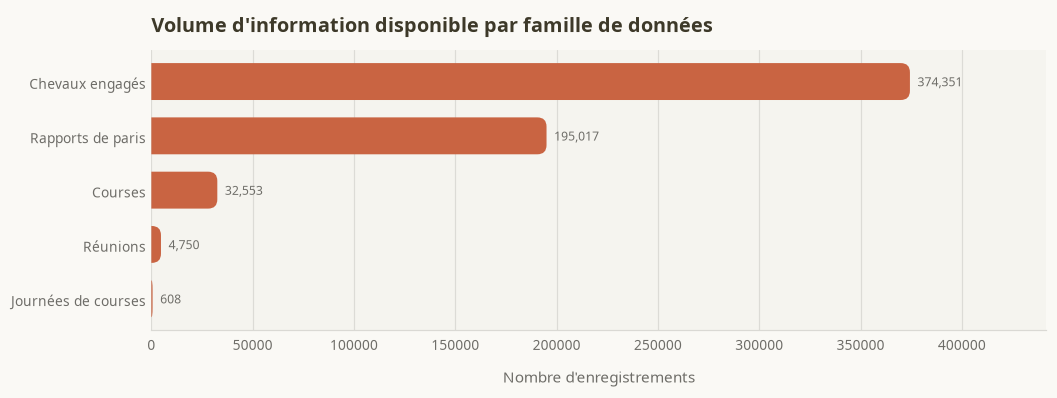

In [4]:
fig, ax = barres(
    panorama["Enregistrements"],
    "Volume d'information disponible par famille de données",
    "Nombre d'enregistrements",
)
plt.show()

**À retenir.** Le socle est complet et homogène : les 608 journées attendues sont présentes, avec
en moyenne 8 réunions, 54 courses et 615 chevaux engagés par jour. Toutes les familles
d'information couvrent l'intégralité du calendrier, sans journée manquante ni période dégarnie.
Le volume est également très déséquilibré d'une famille à l'autre, ce qui est logique : une
journée produit une poignée de réunions, mais plusieurs centaines de fiches de chevaux.

### À quoi ressemble une journée de courses ?

In [5]:
journee_type = pd.DataFrame(
    {
        "Moyenne": [
            volumes["reunion"].where(volumes["reunion"] > 0).mean(),
            volumes["course"].where(volumes["course"] > 0).mean(),
            volumes["course"].sum() / volumes["reunion"].sum(),
            volumes["participant"].sum() / volumes["course"].sum(),
            volumes["rapport"].sum() / volumes["course"].sum(),
        ],
        "Minimum": [
            volumes["reunion"].where(volumes["reunion"] > 0).min(),
            volumes["course"].where(volumes["course"] > 0).min(),
            np.nan,
            np.nan,
            np.nan,
        ],
        "Maximum": [
            volumes["reunion"].max(),
            volumes["course"].max(),
            np.nan,
            np.nan,
            np.nan,
        ],
    },
    index=[
        "Réunions par journée",
        "Courses par journée",
        "Courses par réunion",
        "Chevaux engagés par course",
        "Rapports de paris par course",
    ],
)
display(
    tableau(
        journee_type,
        "La journée de courses moyenne",
        formats={colonne: (lambda v: nombre(v, 1)) for colonne in journee_type.columns},
    )
)

,Moyenne,Minimum,Maximum
Réunions par journée,"7,8","2,0","16,0"
Courses par journée,"53,5","15,0","112,0"
Courses par réunion,"6,9",—,—
Chevaux engagés par course,"11,5",—,—
Rapports de paris par course,"6,0",—,—


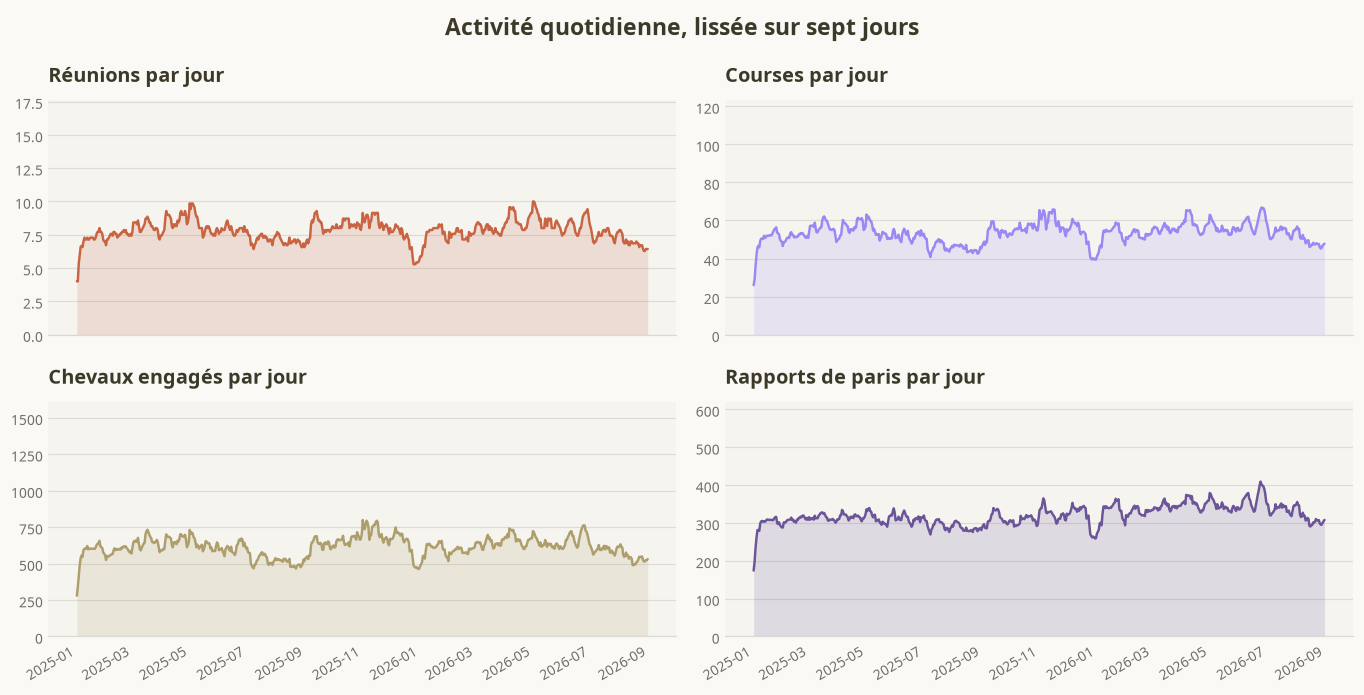

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12.5, 6.4), sharex=True)
series_affichees = [
    ("reunion", "Réunions par jour"),
    ("course", "Courses par jour"),
    ("participant", "Chevaux engagés par jour"),
    ("rapport", "Rapports de paris par jour"),
]
for ax, (colonne, titre), couleur in zip(axes.flat, series_affichees, ds.color_cycle(4)):
    lisse = volumes[colonne].rolling(7, min_periods=1).mean()
    ax.plot(lisse.index, lisse.to_numpy(), color=couleur, linewidth=1.6)
    ax.fill_between(lisse.index, lisse.to_numpy(), color=couleur, alpha=0.16)
    ax.set_title(titre)
    ax.set_ylim(0, float(volumes[colonne].max()) * 1.1)
fig.suptitle("Activité quotidienne, lissée sur sept jours")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

**À retenir.** L'activité est remarquablement régulière d'un bout à l'autre de la période : pas de
mois creux, pas d'interruption. Les variations visibles sont celles du calendrier hippique
lui-même — les grands week-ends chargés alternent avec des journées de semaine plus légères.

<a id="journees"></a>
## 2. Les journées de courses

Une journée de courses correspond à une date du calendrier hippique. Elle rassemble toutes les
réunions organisées ce jour-là, en France comme à l'étranger.

In [7]:
from dataset.load_programmes import load_programmes

df_programmes = load_programmes(start_date, end_date)
df_programmes["date_programme"] = pd.to_datetime(df_programmes["id"], format="%d%m%Y")
df_programmes = df_programmes.sort_values("date_programme", ignore_index=True)

journees_manquantes = sorted(set(jours_attendus) - set(df_programmes["id"]))
display(
    chiffres_cles(
        {
            "Période couverte": f"{debut:%d/%m/%Y} → {fin:%d/%m/%Y}",
            "Journées au calendrier": nombre(len(jours_attendus)),
            "Journées présentes dans la base": nombre(len(df_programmes)),
            "Journées manquantes": nombre(len(journees_manquantes)),
            "Journées entièrement renseignées": f"{nombre(df_programmes['is_scraped'].mean() * 100, 1)} %",
        },
        "Couverture du calendrier",
    )
)

,
Période couverte,01/01/2025 → 31/08/2026
Journées au calendrier,608
Journées présentes dans la base,608
Journées manquantes,0
Journées entièrement renseignées,"100,0 %"


### Toutes les journées ne se ressemblent pas

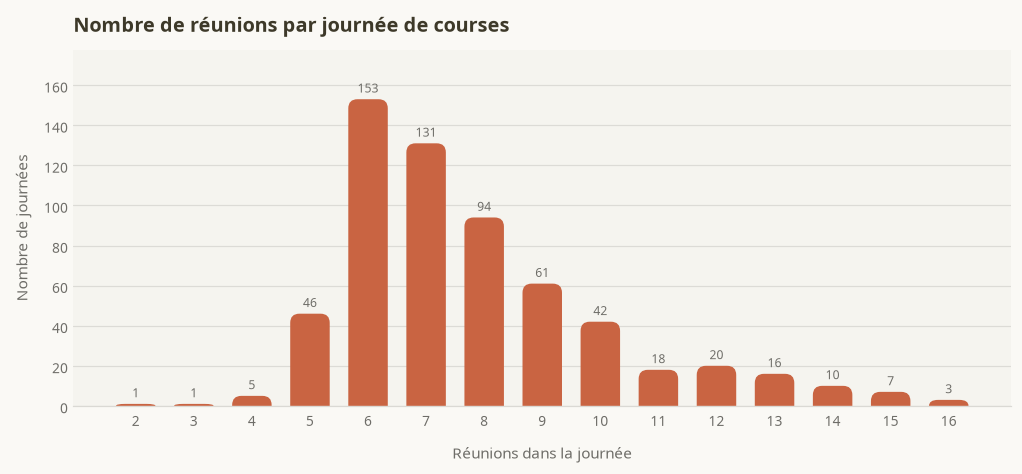

In [8]:
reunions_par_journee = volumes["reunion"].value_counts().sort_index()
fig, ax = barres_verticales(
    reunions_par_journee,
    "Nombre de réunions par journée de courses",
    "Nombre de journées",
)
ax.set_xlabel("Réunions dans la journée")
plt.show()

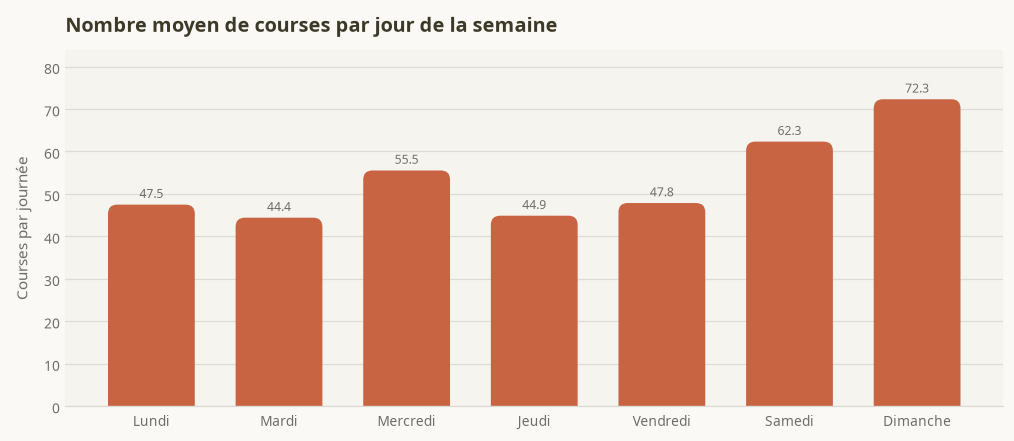

In [9]:
courses_moyennes_jour = volumes["course"].groupby(volumes.index.dayofweek).mean()
courses_moyennes_jour.index = [JOURS[index] for index in courses_moyennes_jour.index]
fig, ax = barres_verticales(
    courses_moyennes_jour,
    "Nombre moyen de courses par jour de la semaine",
    "Courses par journée",
    fmt="{:,.1f}",
)
plt.show()

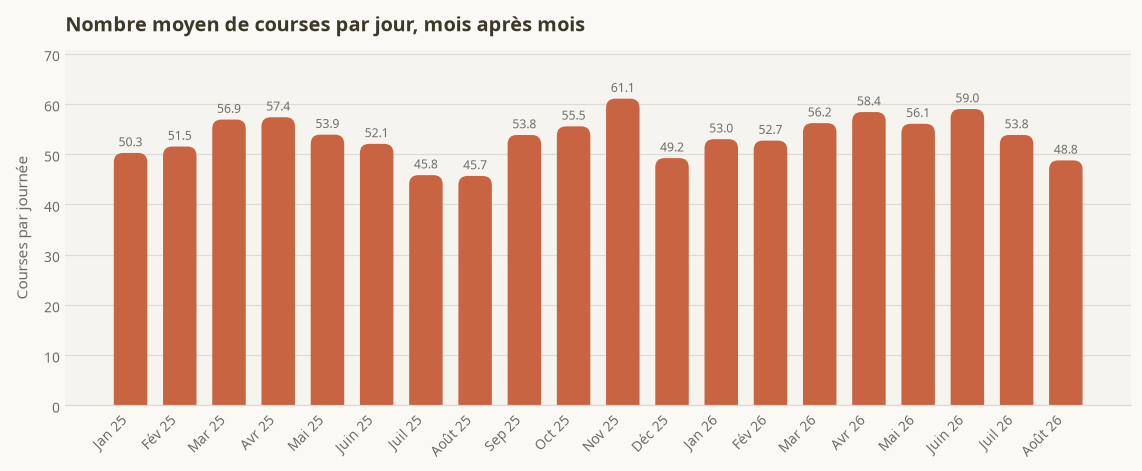

In [10]:
courses_moyennes_mois = volumes["course"].groupby(
    [volumes.index.year, volumes.index.month]
).mean()
courses_moyennes_mois.index = [
    f"{MOIS[mois - 1]} {str(annee)[2:]}" for annee, mois in courses_moyennes_mois.index
]
fig, ax = barres_verticales(
    courses_moyennes_mois,
    "Nombre moyen de courses par jour, mois après mois",
    "Courses par journée",
    fmt="{:,.1f}",
    figsize=(12.5, 4.2),
    rotation=45,
)
plt.show()

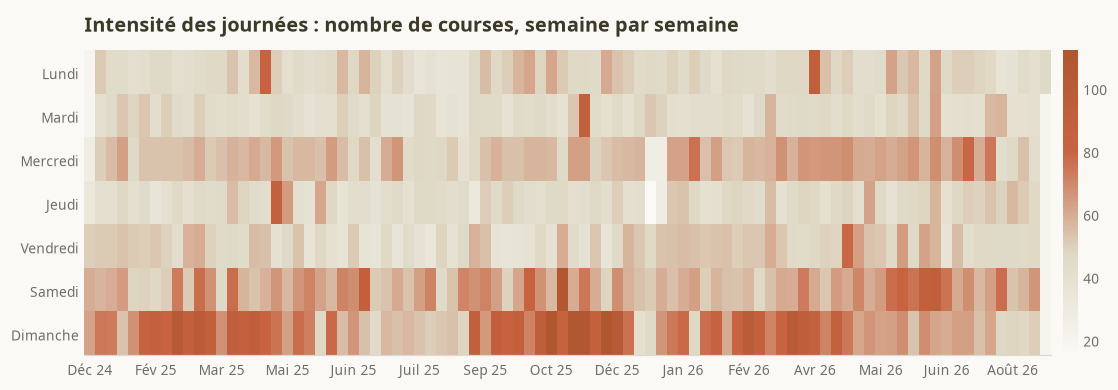

In [11]:
calendrier = volumes[["course"]].copy()
calendrier["semaine"] = calendrier.index.to_period("W").start_time
calendrier["jour"] = calendrier.index.dayofweek
grille = calendrier.pivot_table(index="jour", columns="semaine", values="course", aggfunc="sum")

fig, ax = plt.subplots(figsize=(13.5, 3.6))
image = ax.imshow(
    grille.to_numpy(), aspect="auto", cmap=ds.sequential_cmap("light"), interpolation="nearest"
)
ax.set_yticks(range(7), JOURS)
positions = list(range(0, grille.shape[1], 6))
ax.set_xticks(
    positions,
    [f"{MOIS[grille.columns[position].month - 1]} {grille.columns[position]:%y}" for position in positions],
)
ax.set_title("Intensité des journées : nombre de courses, semaine par semaine")
ax.grid(visible=False)
barre = fig.colorbar(image, ax=ax, pad=0.01)
barre.outline.set_visible(False)
plt.show()

**À retenir.** Le rythme hebdomadaire est très marqué : le dimanche et le samedi concentrent le
plus de courses, avec près de soixante épreuves par journée, contre une cinquantaine en milieu de
semaine. La saisonnalité, elle, est faible : l'été est légèrement plus dense, mais aucune période
de l'année n'est dégarnie. Le calendrier ne présente aucune zone blanche, ce qui autorise des
comparaisons d'une semaine ou d'un mois à l'autre sans correction particulière.

<a id="reunions"></a>
## 3. Les réunions

Une réunion, c'est un lieu et un moment : tel hippodrome, tel après-midi, avec sa météo et son
public. C'est le cadre dans lequel les courses se déroulent.

In [12]:
from dataset.load_reunions import load_reunions

df_reunions = load_reunions(start_date, end_date)
base_reunions = df_reunions.dropna(subset=["raw"]).reset_index(drop=True)
reunions = pd.json_normalize(base_reunions["raw"].tolist())
reunions.insert(0, "id", base_reunions["id"].to_numpy())
reunions.insert(1, "programme_id", base_reunions["id"].str.slice(0, 8).to_numpy())
reunions.insert(2, "date_programme", pd.to_datetime(reunions["programme_id"], format="%d%m%Y"))

display(
    chiffres_cles(
        {
            "Réunions enregistrées": nombre(len(reunions)),
            "Pays représentés": nombre(reunions["pays.code"].nunique()),
            "Hippodromes différents": nombre(reunions["hippodrome.code"].nunique()),
            "Réunions par journée (moyenne)": nombre(len(reunions) / len(df_programmes), 1),
            "Réunions avec météo renseignée": f"{nombre(reunions['meteo.temperature'].notna().mean() * 100, 1)} %",
        },
        "Les réunions en quelques chiffres",
    )
)

,
Réunions enregistrées,4 750
Pays représentés,30
Hippodromes différents,253
Réunions par journée (moyenne),"7,8"
Réunions avec météo renseignée,"97,1 %"


### Où court-on ?

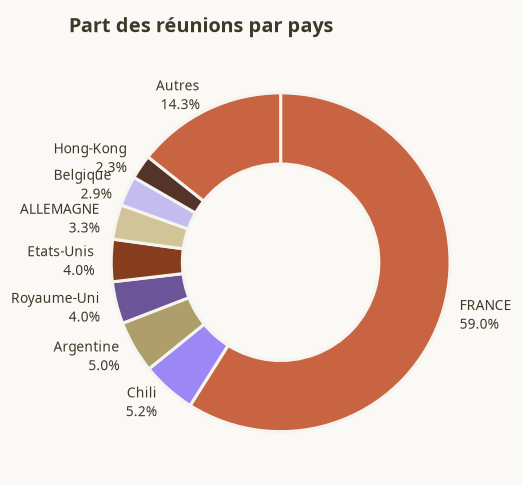

In [13]:
fig, ax = donut(reunions["pays.libelle"].value_counts(), "Part des réunions par pays")
plt.show()

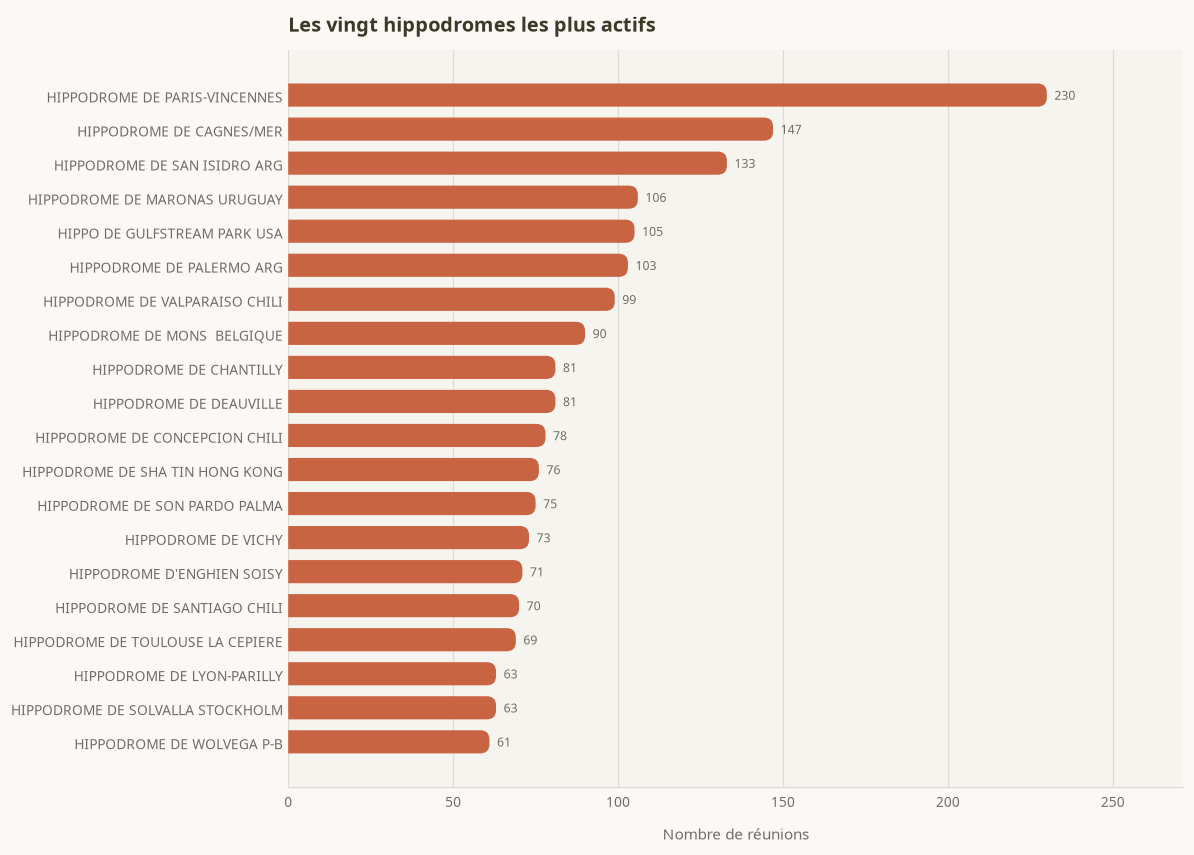

In [14]:
top_hippodromes = reunions["hippodrome.libelleLong"].value_counts().head(20)
fig, ax = barres(
    top_hippodromes, "Les vingt hippodromes les plus actifs", "Nombre de réunions"
)
plt.show()

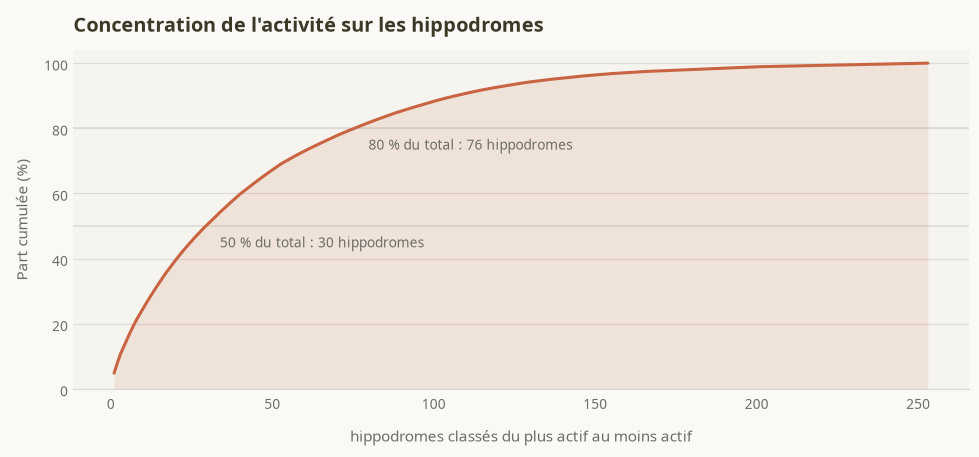

In [15]:
fig, ax = part_cumulee(
    reunions["hippodrome.libelleLong"].value_counts(),
    "Concentration de l'activité sur les hippodromes",
    "hippodromes",
)
plt.show()

**À retenir.** La France représente l'essentiel des réunions, mais la base est loin d'être
franco-centrée : une trentaine de pays y figurent, ce qui reflète l'offre de paris internationaux
du PMU. Côté lieux, l'activité est très concentrée : sur plus de 250 hippodromes recensés, une
vingtaine suffit à représenter la moitié des réunions. Vincennes et les grands hippodromes
parisiens tiennent le haut du classement.

### Dans quelles conditions ?

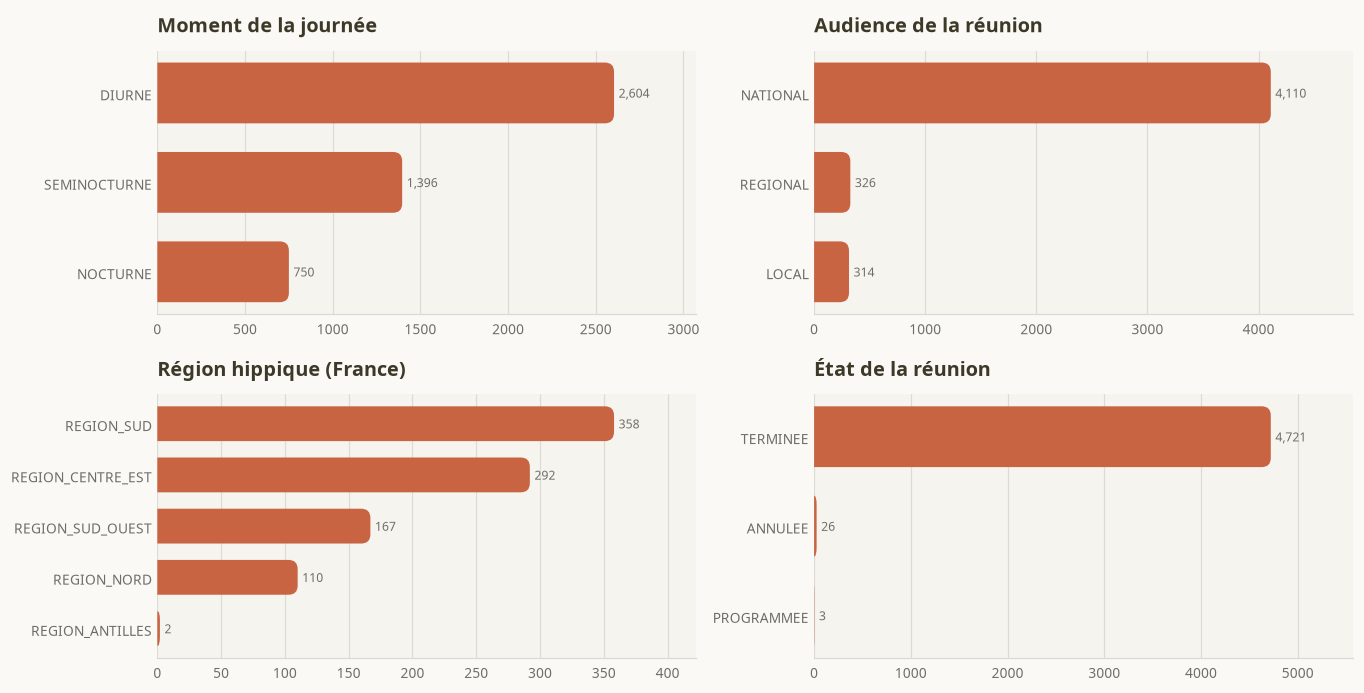

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12.5, 6.4))
for ax, colonne, titre in zip(
    axes.flat,
    ["nature", "audience", "regionHippique", "statut"],
    [
        "Moment de la journée",
        "Audience de la réunion",
        "Région hippique (France)",
        "État de la réunion",
    ],
):
    barh_ax(ax, reunions[colonne].value_counts(), titre, limite=8)
fig.tight_layout()
plt.show()

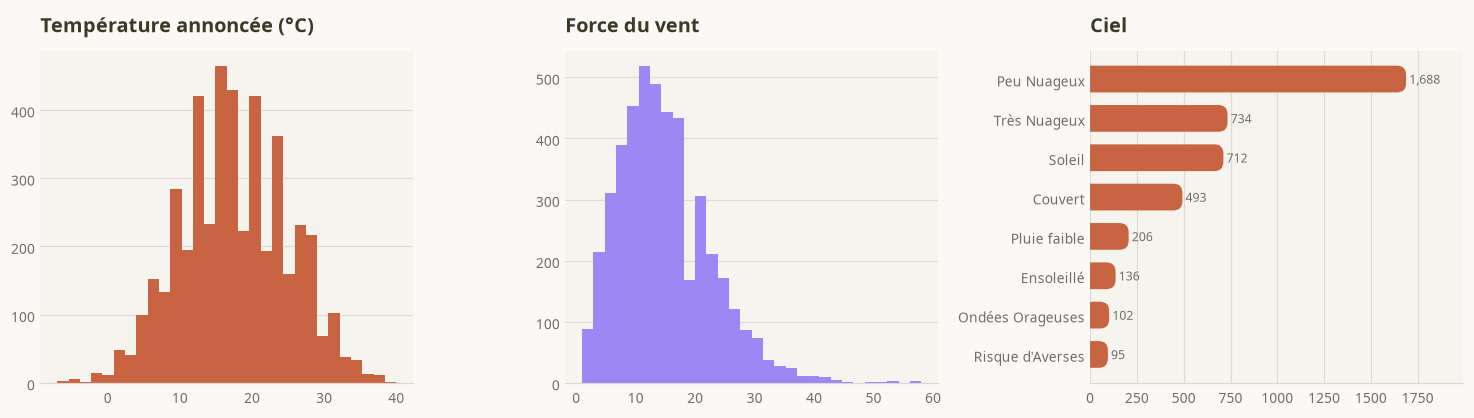

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.9))
axes[0].hist(reunions["meteo.temperature"].dropna(), bins=30, color=THEME["primary"])
axes[0].set_title("Température annoncée (°C)")
axes[1].hist(reunions["meteo.forceVent"].dropna(), bins=30, color=ds.color_cycle(2)[1])
axes[1].set_title("Force du vent")
barh_ax(axes[2], reunions["meteo.nebulositeLibelleCourt"].value_counts(), "Ciel", limite=8)
fig.tight_layout()
plt.show()

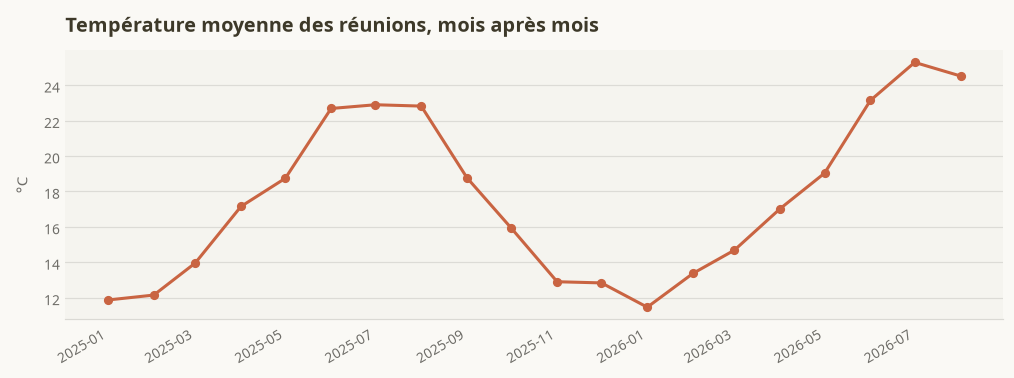

In [18]:
temperature_mensuelle = (
    reunions.dropna(subset=["meteo.temperature"])
    .groupby(pd.Grouper(key="date_programme", freq="MS"))["meteo.temperature"]
    .mean()
)
fig, ax = figure("Température moyenne des réunions, mois après mois", (11, 3.6))
ax.plot(temperature_mensuelle.index, temperature_mensuelle.to_numpy(), color=THEME["primary"], marker="o")
ax.set_ylabel("°C")
fig.autofmt_xdate()
plt.show()

**À retenir.** Les réunions se tiennent très majoritairement en journée, devant un public
national. La météo est renseignée pour 97 % d'entre elles et suit fidèlement le cycle des saisons,
ce qui en fait une information exploitable sans retraitement. En revanche, la région hippique
n'est précisée que pour une réunion sur cinq : elle ne concerne que les réunions françaises et ne
peut donc pas servir de critère de comparaison général.

### Trot, galop, obstacle : les familles de courses

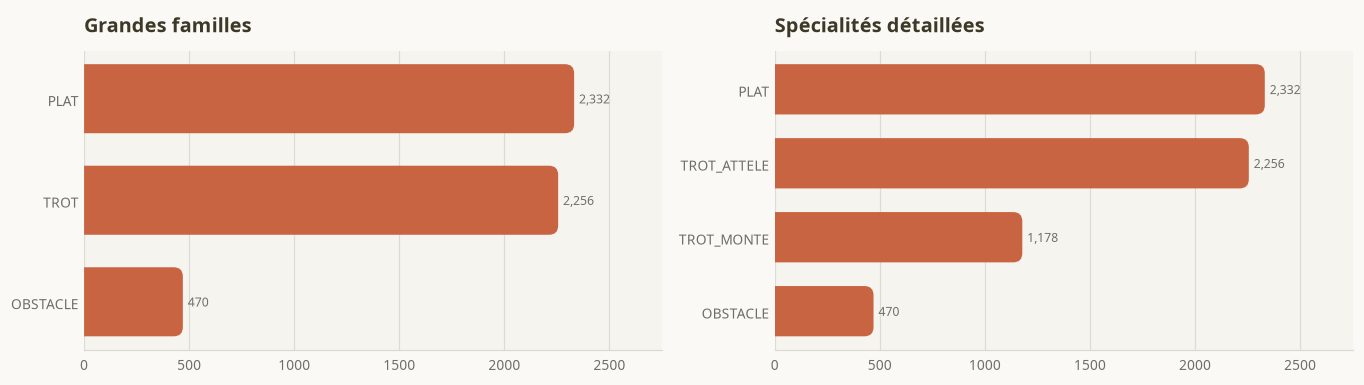

In [19]:
def taille_liste(valeur):
    return len(valeur) if isinstance(valeur, list) else 0


reunions["nb_disciplines"] = reunions["disciplinesMere"].map(taille_liste)
reunions["nb_specialites"] = reunions["specialites"].map(taille_liste)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.6))
barh_ax(axes[0], reunions["disciplinesMere"].explode().value_counts(), "Grandes familles")
barh_ax(axes[1], reunions["specialites"].explode().value_counts(), "Spécialités détaillées")
fig.tight_layout()
plt.show()

In [20]:
mono = reunions[reunions["nb_disciplines"] == 1].copy()
mono["discipline_mere"] = mono["disciplinesMere"].str[0]
mono_explose = mono.explode("specialites").reset_index(drop=True)
correspondance = (
    pd.crosstab(mono_explose["discipline_mere"], mono_explose["specialites"])
    .rename_axis(index="Grande famille", columns="Spécialité")
)
display(
    tableau(
        correspondance,
        "Comment les spécialités se rattachent aux grandes familles (réunions à une seule famille)",
        formats={colonne: (lambda v: nombre(v) if v else "—") for colonne in correspondance.columns},
    )
)

Spécialité,OBSTACLE,PLAT,TROT_ATTELE,TROT_MONTE
Grande famille,,,,
OBSTACLE,193,—,—,—
PLAT,—,2 056,—,—
TROT,—,—,2 195,1 172


**À retenir.** Les deux nomenclatures se recoupent parfaitement : le trot se subdivise en attelé
et monté, le galop en plat, et les obstacles forment leur propre famille. Une réunion sur trois
mélange plusieurs spécialités — typiquement une réunion de trot qui alterne attelé et monté. Il
faut donc raisonner au niveau de la course, et non de la réunion, dès qu'on s'intéresse à la
discipline.

<a id="courses"></a>
## 4. Les courses

C'est le cœur de la base : l'épreuve, avec sa discipline, sa distance, sa dotation, son heure de
départ et son résultat.

In [21]:
from dataset.load_courses import load_courses

df_courses = load_courses(start_date, end_date)
df_courses = df_courses.merge(
    reunions[["id", "hippodrome.libelleLong", "pays.libelle"]].rename(
        columns={
            "id": "reunion_id",
            "hippodrome.libelleLong": "hippodrome",
            "pays.libelle": "pays",
        }
    ),
    on="reunion_id",
    how="left",
)
df_courses["vitesse_kmh"] = (
    df_courses["distance"] / df_courses["duree_course_ms"].where(df_courses["duree_course_ms"] > 0) * 3600
)

display(
    chiffres_cles(
        {
            "Courses enregistrées": nombre(len(df_courses)),
            "Distance médiane": nombre(df_courses["distance"].median(), 0, " m"),
            "Chevaux au départ (moyenne)": nombre(df_courses["nombre_declares_partants"].mean(), 1),
            "Dotation médiane": nombre(df_courses["montant_prix"].median(), 0, " €"),
            "Courses chronométrées": f"{nombre(df_courses['duree_course_ms'].gt(0).mean() * 100, 1)} %",
            "Types de paris offerts (médiane)": nombre(df_courses["nombre_paris"].median()),
        },
        "Les courses en quelques chiffres",
    )
)

,
Courses enregistrées,32 553
Distance médiane,2 200 m
Chevaux au départ (moyenne),"11,5"
Dotation médiane,19 500 €
Courses chronométrées,"97,6 %"
Types de paris offerts (médiane),14


### Quelles disciplines ?

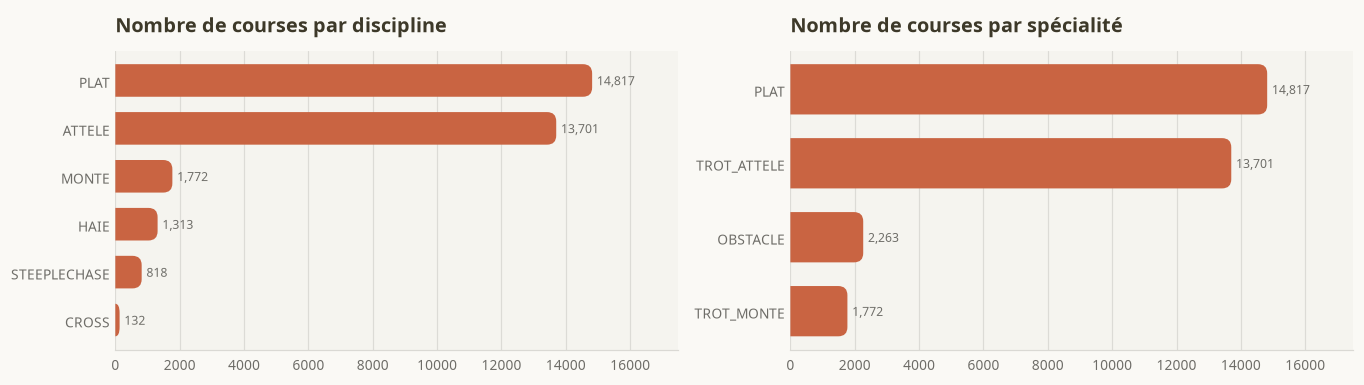

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.6))
barh_ax(axes[0], df_courses["discipline"].value_counts(), "Nombre de courses par discipline")
barh_ax(axes[1], df_courses["specialite"].value_counts(), "Nombre de courses par spécialité")
fig.tight_layout()
plt.show()

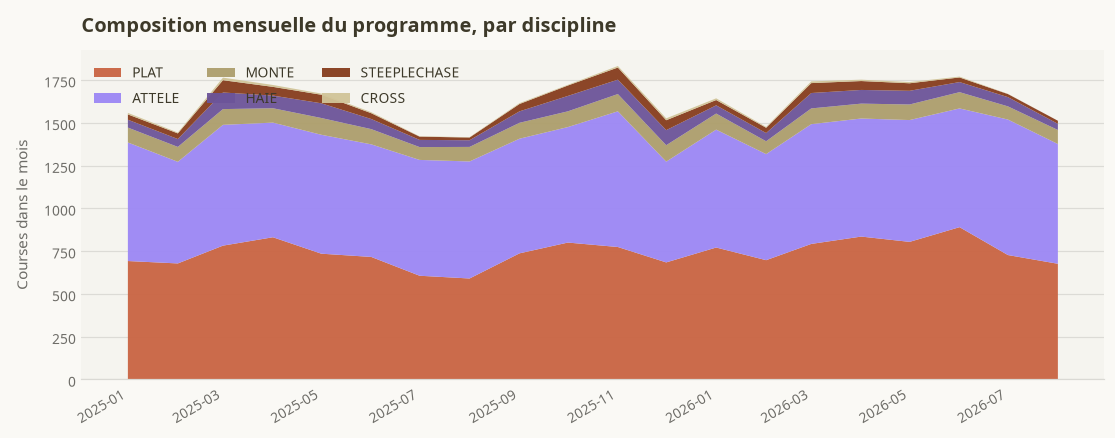

In [23]:
mensuel_discipline = (
    df_courses.groupby([pd.Grouper(key="date_programme", freq="MS"), "discipline"])
    .size()
    .unstack("discipline")
    .fillna(0)
)
ordre_disciplines = mensuel_discipline.sum().sort_values(ascending=False).index
fig, ax = figure("Composition mensuelle du programme, par discipline", (12, 4.4))
ax.stackplot(
    mensuel_discipline.index,
    [mensuel_discipline[discipline].to_numpy() for discipline in ordre_disciplines],
    labels=list(ordre_disciplines),
    colors=ds.color_cycle(len(ordre_disciplines)),
    alpha=0.95,
)
ax.legend(ncols=3, loc="upper left")
ax.set_ylabel("Courses dans le mois")
fig.autofmt_xdate()
plt.show()

In [24]:
profil_disciplines = df_courses.groupby("discipline", observed=True).agg(
    courses=("id", "size"),
    distance_mediane=("distance", "median"),
    partants_moyens=("nombre_declares_partants", "mean"),
    dotation_mediane=("montant_prix", "median"),
    vitesse_moyenne=("vitesse_kmh", "mean"),
    duree_mediane=("duree_course_ms", "median"),
)
profil_disciplines["duree_mediane"] = profil_disciplines["duree_mediane"] / 60_000
profil_disciplines = profil_disciplines.sort_values("courses", ascending=False)
profil_disciplines.columns = [
    "Courses",
    "Distance médiane (m)",
    "Chevaux au départ",
    "Dotation médiane (€)",
    "Vitesse moyenne (km/h)",
    "Durée médiane (min)",
]
display(
    tableau(
        profil_disciplines,
        "Portrait de chaque discipline",
        formats={
            "Courses": lambda v: nombre(v),
            "Distance médiane (m)": lambda v: nombre(v),
            "Chevaux au départ": lambda v: nombre(v, 1),
            "Dotation médiane (€)": lambda v: nombre(v),
            "Vitesse moyenne (km/h)": lambda v: nombre(v, 1),
            "Durée médiane (min)": lambda v: nombre(v, 1),
        },
        barres=["Courses"],
    )
)

,Courses,Distance médiane (m),Chevaux au départ,Dotation médiane (€),Vitesse moyenne (km/h),Durée médiane (min)
discipline,,,,,,
PLAT,14 817,1 600,"10,8",16 500,"58,4","1,6"
ATTELE,13 701,2 650,"12,4",19 000,"47,8","3,3"
MONTE,1 772,2 700,"11,7",26 000,"48,2","3,4"
HAIE,1 313,3 600,"11,0",32 000,"49,2","4,4"
STEEPLECHASE,818,3 900,"9,3",34 000,"48,0","4,9"
CROSS,132,4 700,"8,2",28 000,"79,7","6,3"


**À retenir.** Le plat et le trot attelé se partagent près de neuf courses sur dix, à parts égales.
Les obstacles (haies, steeple-chase, cross) et le trot monté complètent le tableau. Chaque
discipline a sa signature : le trot se court sur des distances longues (2 000 à 2 800 m) à une
quarantaine de kilomètres à l'heure, le plat sur des distances plus variables mais à près de
60 km/h. Ces ordres de grandeur sont cohérents avec la réalité du terrain, ce qui confirme la
fiabilité des distances et des chronos enregistrés.

### Distances, chevaux au départ et dotations

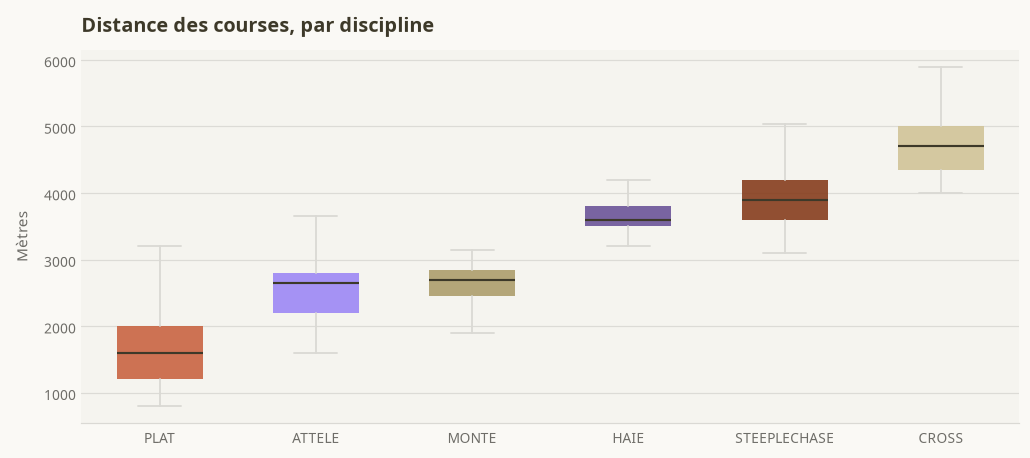

In [25]:
groupes_distance = {
    discipline: sous_ensemble["distance"].dropna()
    for discipline, sous_ensemble in df_courses.groupby("discipline", observed=True)
}
groupes_distance = dict(sorted(groupes_distance.items(), key=lambda item: item[1].median()))
fig, ax = boites(groupes_distance, "Distance des courses, par discipline", "Mètres")
plt.show()

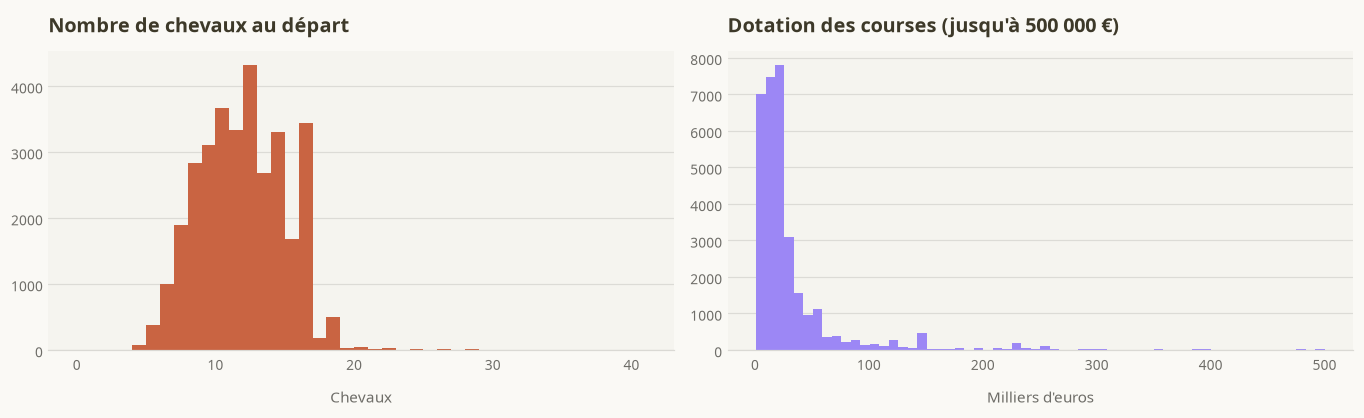

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.9))
axes[0].hist(df_courses["nombre_declares_partants"], bins=range(0, 42), color=THEME["primary"])
axes[0].set_title("Nombre de chevaux au départ")
axes[0].set_xlabel("Chevaux")
axes[1].hist(
    df_courses.loc[df_courses["montant_prix"].between(1, 500_000), "montant_prix"] / 1000,
    bins=60,
    color=ds.color_cycle(2)[1],
)
axes[1].set_title("Dotation des courses (jusqu'à 500 000 €)")
axes[1].set_xlabel("Milliers d'euros")
fig.tight_layout()
plt.show()

In [27]:
dotations_extremes = (
    df_courses[df_courses["montant_prix"] > 1_000_000]
    .groupby("pays", observed=True)
    .agg(courses=("id", "size"), dotation_mediane=("montant_prix", "median"))
    .sort_values("courses", ascending=False)
)
dotations_extremes.columns = ["Courses concernées", "Dotation médiane affichée"]
display(
    tableau(
        dotations_extremes,
        "Les dotations supérieures à un million : presque toujours des courses étrangères",
        formats={
            "Courses concernées": lambda v: nombre(v),
            "Dotation médiane affichée": lambda v: nombre(v),
        },
    )
)

,Courses concernées,Dotation médiane affichée
pays,,
Etats-Unis,18,1 923 580
Royaume-Uni,18,1 274 055
Hong-Kong,16,2 968 800
Emirats arabes unis,6,1 571 340
Indetermine,5,1 608 100
Arabie saoudite,4,11 060 585
FRANCE,3,1 500 000
Irlande,3,1 250 000
Australie,1,6 010 300


**À retenir.** Une course rassemble le plus souvent entre 9 et 15 chevaux, pour une dotation
médiane de 19 500 €. La distribution des dotations est très étirée : quelques dizaines de courses
affichent des montants supérieurs au million. Il s'agit presque exclusivement d'épreuves
étrangères, dont la dotation est exprimée dans la devise locale (yen, dollar de Hong Kong...).
**Les montants ne sont donc comparables entre eux qu'à l'intérieur d'un même pays.**

### Quand les courses ont-elles lieu ?

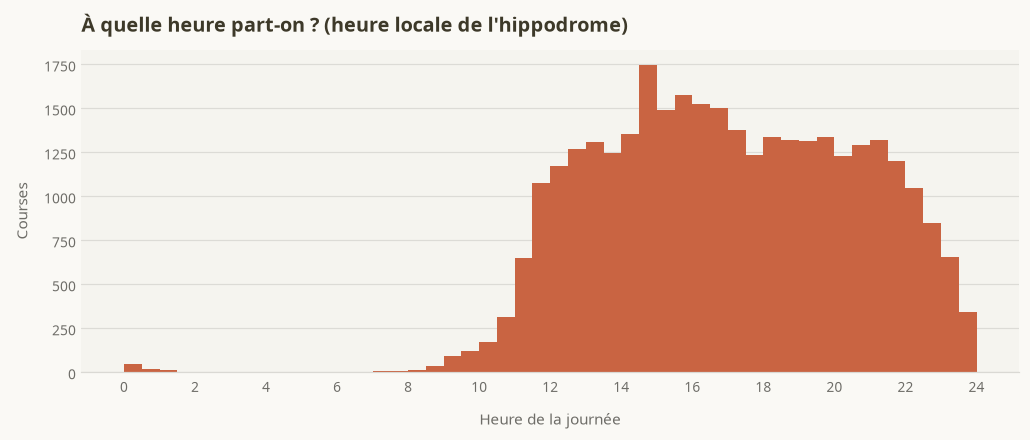

In [28]:
heures = df_courses["heure_depart_locale"].dt.hour + df_courses["heure_depart_locale"].dt.minute / 60
fig, ax = figure("À quelle heure part-on ? (heure locale de l'hippodrome)", (11, 3.8))
ax.hist(heures.dropna(), bins=np.arange(0, 24.5, 0.5), color=THEME["primary"])
ax.set_xlabel("Heure de la journée")
ax.set_xticks(range(0, 25, 2))
ax.set_ylabel("Courses")
plt.show()

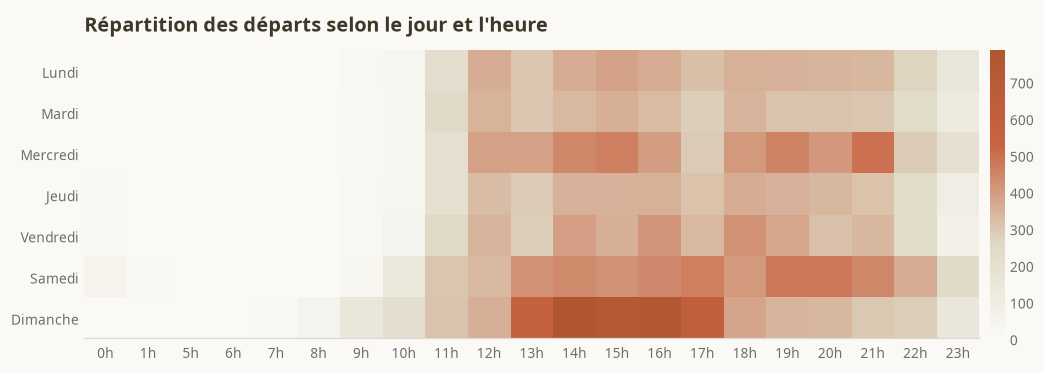

In [29]:
grille_horaire = pd.crosstab(
    df_courses["date_programme"].dt.dayofweek, df_courses["heure_depart_locale"].dt.hour
)
grille_horaire.index = [JOURS[index] for index in grille_horaire.index]
fig, ax = plt.subplots(figsize=(12.5, 3.4))
image = ax.imshow(grille_horaire.to_numpy(), aspect="auto", cmap=ds.sequential_cmap("light"))
ax.set_yticks(range(len(grille_horaire)), grille_horaire.index)
ax.set_xticks(range(len(grille_horaire.columns)), [f"{heure}h" for heure in grille_horaire.columns])
ax.set_title("Répartition des départs selon le jour et l'heure")
ax.grid(visible=False)
barre = fig.colorbar(image, ax=ax, pad=0.01)
barre.outline.set_visible(False)
plt.show()

**À retenir.** Les départs se massent l'après-midi, entre 12 h et 18 h, avec un pic marqué en début
d'après-midi. Une activité résiduelle subsiste en soirée (réunions nocturnes) et au petit matin :
ce sont les courses asiatiques et australiennes, dont l'heure locale n'a rien à voir avec l'heure
française. La grille croisée jour/heure montre un motif stable, sans plage horaire délaissée.

### Le terrain et l'offre de paris

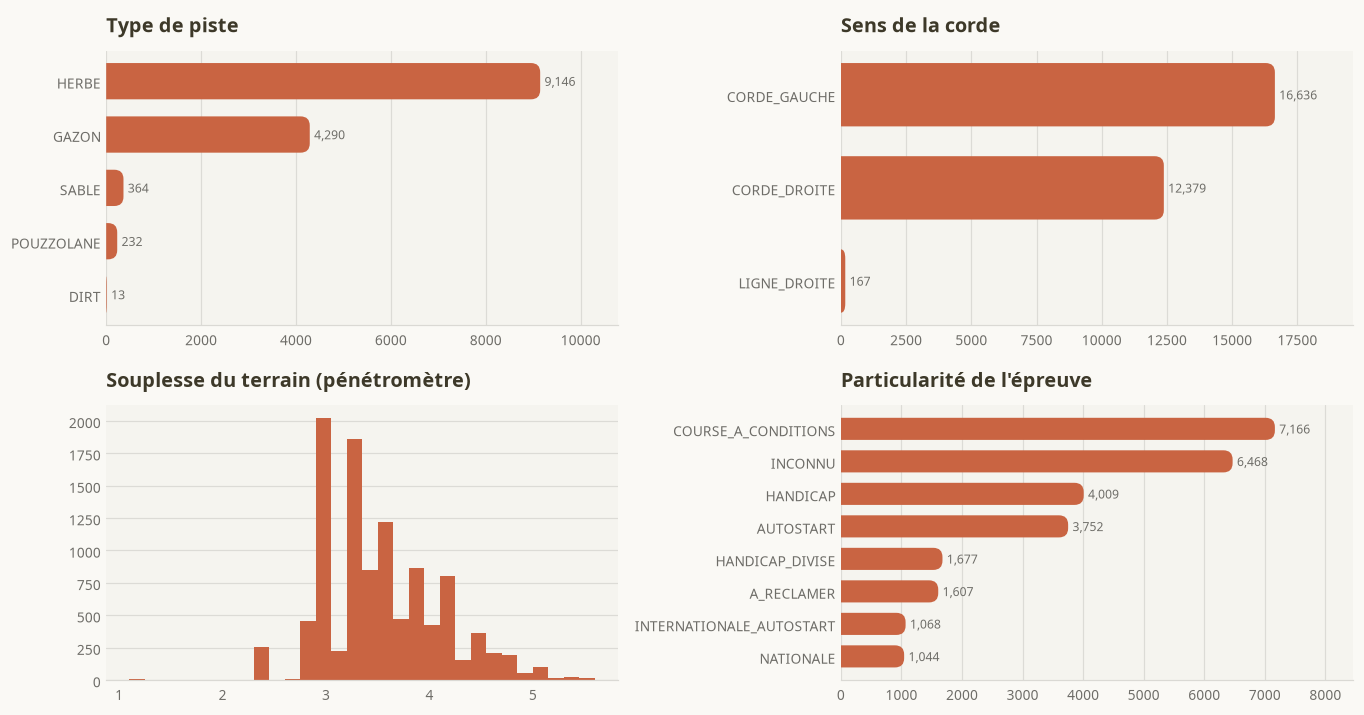

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(12.5, 6.6))
barh_ax(axes[0][0], df_courses["type_piste"].value_counts(), "Type de piste", limite=8)
barh_ax(axes[0][1], df_courses["corde"].value_counts(), "Sens de la corde", limite=8)
axes[1][0].hist(df_courses["penetrometre_valeur"].dropna(), bins=30, color=THEME["primary"])
axes[1][0].set_title("Souplesse du terrain (pénétromètre)")
barh_ax(
    axes[1][1],
    df_courses["categorie_particularite"].value_counts(),
    "Particularité de l'épreuve",
    limite=8,
)
fig.tight_layout()
plt.show()

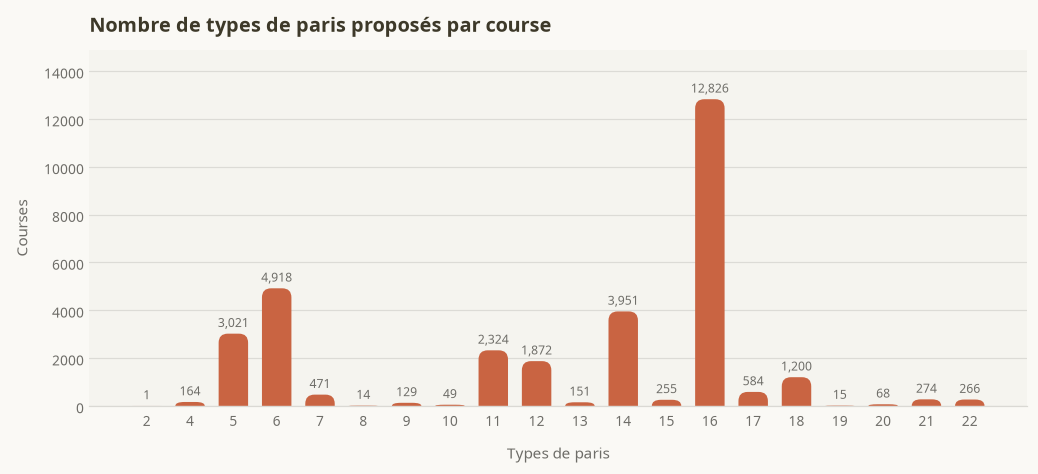

In [31]:
fig, ax = barres_verticales(
    df_courses["nombre_paris"].value_counts().sort_index(),
    "Nombre de types de paris proposés par course",
    "Courses",
)
ax.set_xlabel("Types de paris")
plt.show()

**À retenir.** Le terrain n'est décrit que partiellement : le type de piste est connu pour 43 % des
courses et la mesure du pénétromètre pour un tiers, essentiellement en plat et sur les obstacles.
Le sens de la corde, en revanche, est presque toujours renseigné. L'offre de paris est large :
une course propose en général une quinzaine de formules, et jusqu'à vingt-deux pour les grandes
épreuves.

<a id="chevaux"></a>
## 5. Les chevaux engagés

Pour chaque course, la base conserve la fiche de tous les chevaux déclarés : leur profil, leur
palmarès, leur cote au départ et leur place à l'arrivée.

In [32]:
from dataset.load_participants import load_participants

df_participants = load_participants(start_date, end_date)
partants = df_participants[df_participants["statut"] == "PARTANT"]

display(
    chiffres_cles(
        {
            "Fiches de chevaux engagés": nombre(len(df_participants)),
            "Partants effectifs": nombre(len(partants)),
            "Non-partants (forfaits)": f"{nombre((df_participants['statut'] == 'NON_PARTANT').sum())}"
            f" ({nombre((df_participants['statut'] == 'NON_PARTANT').mean() * 100, 1)} %)",
            "Chevaux différents": nombre(df_participants["nom"].nunique()),
            "Jockeys et drivers différents": nombre(df_participants["driver"].nunique()),
            "Entraîneurs différents": nombre(df_participants["entraineur"].nunique()),
            "Place à l'arrivée connue": f"{nombre(df_participants['ordre_arrivee'].notna().mean() * 100, 1)} %",
        },
        "Les chevaux engagés en quelques chiffres",
    )
)

,
Fiches de chevaux engagés,374 351
Partants effectifs,360 176
Non-partants (forfaits),"14 175 (3,8 %)"
Chevaux différents,71 887
Jockeys et drivers différents,8 742
Entraîneurs différents,9 822
Place à l'arrivée connue,"83,0 %"


### Le profil des chevaux

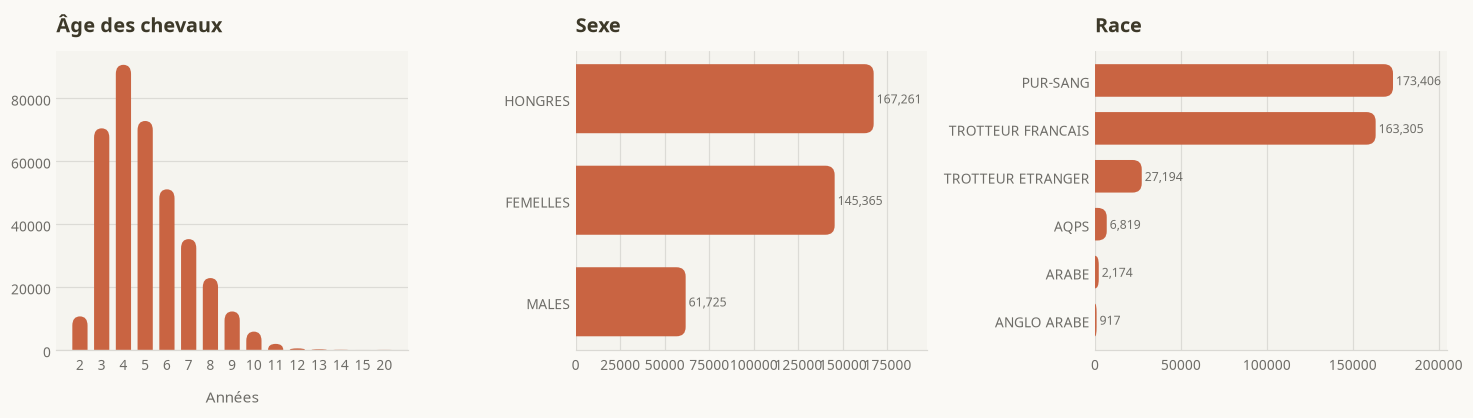

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.9))
ages = df_participants["age"].value_counts().sort_index()
axes[0].bar([str(index) for index in ages.index], ages.to_numpy(dtype=float), color=THEME["primary"], width=0.7)
ds.rounded_bars(axes[0])
axes[0].set_title("Âge des chevaux")
axes[0].set_xlabel("Années")
barh_ax(axes[1], df_participants["sexe"].value_counts(), "Sexe")
barh_ax(axes[2], df_participants["race"].value_counts(), "Race", limite=6)
fig.tight_layout()
plt.show()

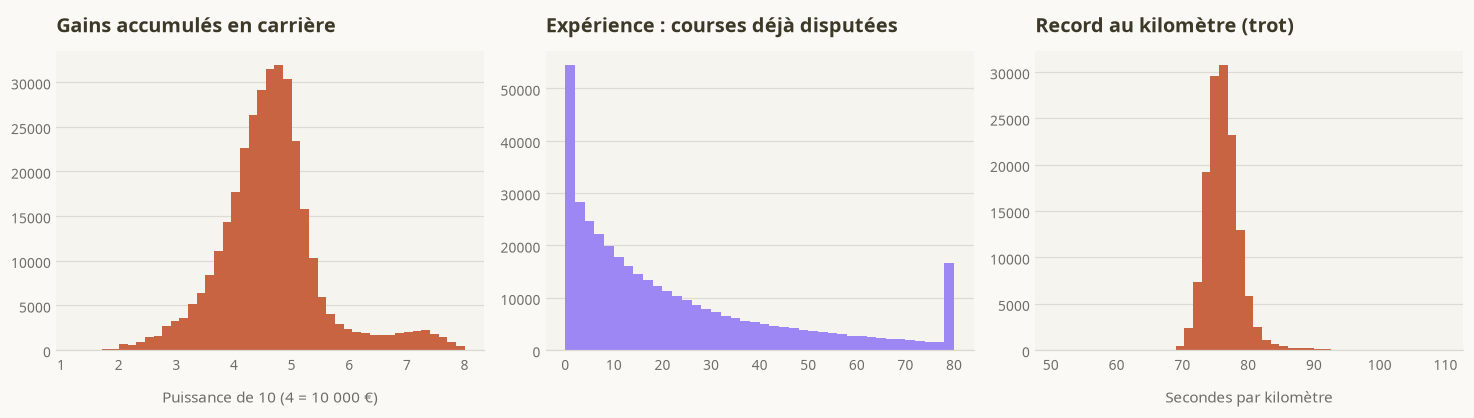

In [34]:
gains_euros = df_participants["gains_carriere"].dropna() / 100
reduction = df_participants.loc[
    df_participants["reduction_kilometrique"].between(50_000, 110_000), "reduction_kilometrique"
] / 1000

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.9))
axes[0].hist(np.log10(gains_euros[gains_euros > 0]), bins=45, color=THEME["primary"])
axes[0].set_title("Gains accumulés en carrière")
axes[0].set_xlabel("Puissance de 10 (4 = 10 000 €)")
axes[1].hist(df_participants["nombre_courses"].clip(upper=80).dropna(), bins=40, color=ds.color_cycle(2)[1])
axes[1].set_title("Expérience : courses déjà disputées")
axes[2].hist(reduction, bins=45, color=THEME["primary"])
axes[2].set_title("Record au kilomètre (trot)")
axes[2].set_xlabel("Secondes par kilomètre")
fig.tight_layout()
plt.show()

**À retenir.** Les chevaux engagés ont le plus souvent entre 3 et 7 ans, avec un pic à 4 et 5 ans.
Le trotteur français domine largement l'effectif, devant le pur-sang. Les gains en carrière
s'étalent sur plusieurs ordres de grandeur — de quelques milliers d'euros pour un débutant à
plusieurs millions pour les cracks — avec une médiane autour de 35 000 €. Le record au kilomètre,
propre au trot, se concentre entre 72 et 80 secondes, ce qui correspond aux valeurs de référence
de la discipline.

### Équipement et incidents de course

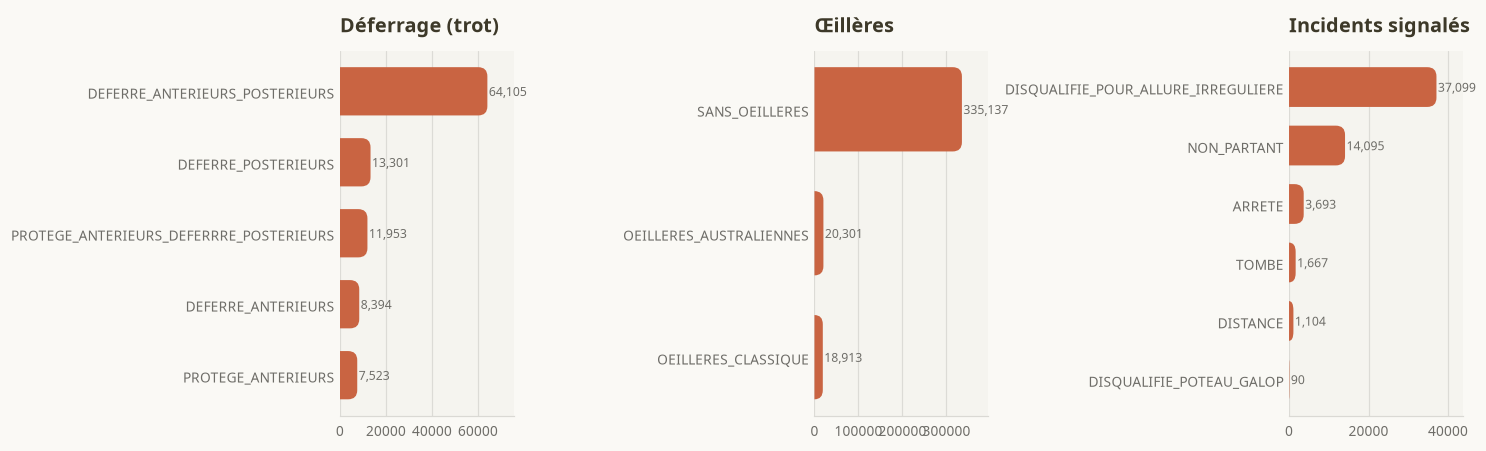

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))
barh_ax(axes[0], df_participants["deferre"].value_counts(), "Déferrage (trot)", limite=5)
barh_ax(axes[1], df_participants["oeilleres"].value_counts(), "Œillères", limite=5)
barh_ax(axes[2], df_participants["incident"].value_counts(), "Incidents signalés", limite=6)
fig.tight_layout()
plt.show()

**À retenir.** Un cheval sur six connaît un incident déclaré, la disqualification pour allure
irrégulière étant de loin le cas le plus fréquent au trot. Ces incidents expliquent l'essentiel
des places à l'arrivée manquantes : un cheval disqualifié ou tombé n'est pas classé. Le détail du
déferrage n'est renseigné que pour les trotteurs, soit un peu moins d'un tiers des fiches.

### Les cotes

In [36]:
cotes = partants.loc[partants["cote_directe"].between(1, 998), "cote_directe"]
display(
    chiffres_cles(
        {
            "Cote au départ disponible": f"{nombre(df_participants['cote_directe'].notna().mean() * 100, 1)} %",
            "Cote de la veille disponible": f"{nombre(df_participants['cote_reference'].notna().mean() * 100, 1)} %",
            "Cote médiane au départ": nombre(cotes.median(), 1),
            "Cote médiane du favori": nombre(
                partants.loc[partants["cote_directe"].between(1, 998)]
                .groupby("course_id")["cote_directe"].min().median(), 2
            ),
            "Valeurs de remplissage à écarter (999)": nombre((df_participants["cote_directe"] == 999).sum()),
        },
        "Ce que l'on sait des cotes",
    )
)

,
Cote au départ disponible,"91,9 %"
Cote de la veille disponible,"86,9 %"
Cote médiane au départ,"15,0"
Cote médiane du favori,"2,80"
Valeurs de remplissage à écarter (999),1 392


In [ ]:
fig, ax = figure("Répartition des cotes au moment du départ", (11, 3.9))
ax.hist(cotes, bins=np.logspace(np.log10(1), np.log10(1000), 60), color=THEME["primary"])
ax.set_xscale("log")
ax.set_xlabel("Cote (échelle logarithmique)")
ax.set_ylabel("Chevaux")
plt.show()

#### Les cotes disent-elles vrai ?

Un cheval coté 5 contre 1 devrait gagner environ une course sur cinq. Comparer cette promesse au
résultat réellement observé permet de vérifier d'un seul coup d'œil la qualité de trois
informations : la cote, la place à l'arrivée, et le lien entre les deux.

In [37]:
courses_avec_vainqueur = pd.Index(
    df_participants.loc[df_participants["ordre_arrivee"] == 1, "course_id"].unique()
)
courants = df_participants[
    (df_participants["statut"] == "PARTANT")
    & df_participants["cote_directe"].between(1, 998)
    & df_participants["course_id"].isin(courses_avec_vainqueur)
].copy()
courants["gagnant"] = courants["ordre_arrivee"].eq(1)
courants["tranche"] = pd.cut(
    courants["cote_directe"],
    bins=[1, 2, 3, 4, 6, 8, 12, 18, 25, 40, 70, 1000],
    right=False,
)

calibration = courants.groupby("tranche", observed=True).agg(
    chevaux=("gagnant", "size"),
    taux_victoire=("gagnant", "mean"),
    promesse=("cote_directe", lambda serie: (1 / serie).mean()),
)
calibration["ratio"] = calibration["taux_victoire"] / calibration["promesse"]
calibration.index = [
    f"{int(tranche.left)} à {int(tranche.right)}" for tranche in calibration.index
]
calibration.columns = [
    "Chevaux concernés",
    "Victoires observées (%)",
    "Chances annoncées par la cote (%)",
    "Observé / annoncé",
]
calibration["Victoires observées (%)"] *= 100
calibration["Chances annoncées par la cote (%)"] *= 100
display(
    tableau(
        calibration.rename_axis("Cote au départ"),
        "Ce que promet la cote, et ce qui se produit vraiment",
        formats={
            "Chevaux concernés": lambda v: nombre(v),
            "Victoires observées (%)": lambda v: nombre(v, 1),
            "Chances annoncées par la cote (%)": lambda v: nombre(v, 1),
            "Observé / annoncé": lambda v: nombre(v, 2),
        },
        barres=["Chevaux concernés"],
    )
)

,Chevaux concernés,Victoires observées (%),Chances annoncées par la cote (%),Observé / annoncé
Cote au départ,,,,
1 à 2,5 387,"53,7","61,1","0,88"
2 à 3,12 679,"35,9","40,9","0,88"
3 à 4,15 930,"25,6","29,1","0,88"
4 à 6,31 284,"18,4","20,5","0,90"
6 à 8,27 899,"12,9","14,5","0,89"
8 à 12,44 430,"8,9","10,5","0,85"
12 à 18,45 005,"6,0","7,1","0,84"
18 à 25,34 236,"3,9","4,9","0,80"
25 à 40,41 167,"2,4","3,3","0,75"


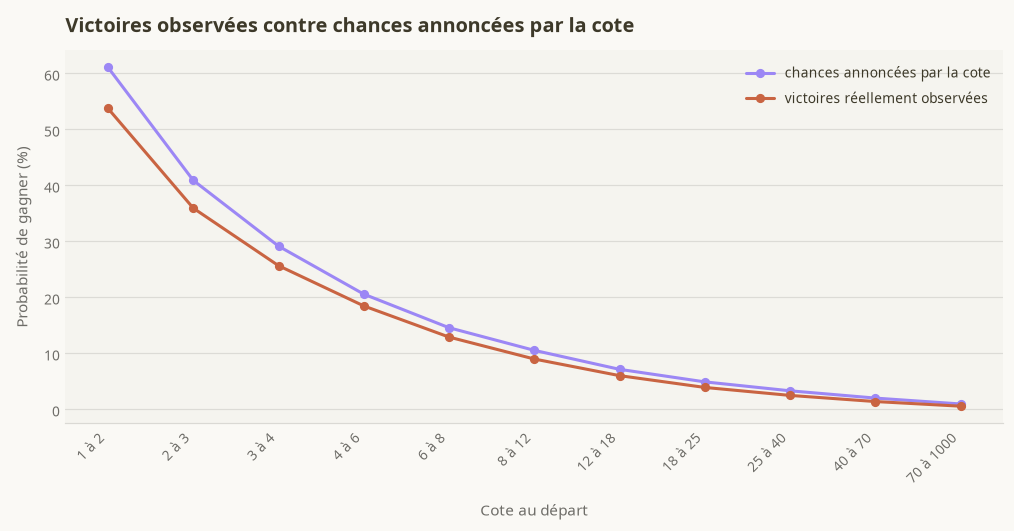

In [38]:
fig, ax = figure("Victoires observées contre chances annoncées par la cote", (11, 4.4))
positions = np.arange(len(calibration))
ax.plot(
    positions,
    calibration["Chances annoncées par la cote (%)"].to_numpy(),
    marker="o",
    color=ds.color_cycle(2)[1],
    label="chances annoncées par la cote",
)
ax.plot(
    positions,
    calibration["Victoires observées (%)"].to_numpy(),
    marker="o",
    color=THEME["primary"],
    label="victoires réellement observées",
)
ax.set_xticks(positions, calibration.index, rotation=45, ha="right")
ax.set_ylabel("Probabilité de gagner (%)")
ax.set_xlabel("Cote au départ")
ax.legend()
plt.show()

**À retenir.** Les deux courbes se suivent de très près : les cotes enregistrées sont cohérentes
avec les résultats, ce qui valide à la fois les cotes et les arrivées. L'écart systématique entre
les deux — la victoire observée vaut environ 88 % de la promesse pour les favoris — correspond au
prélèvement du PMU sur les enjeux. Cet écart se creuse à mesure que la cote monte : il tombe
autour de 0,6 pour les chevaux cotés à plus de 70 contre 1. Autrement dit, **les outsiders sont
systématiquement surévalués par le marché**, un phénomène bien documenté dans les paris hippiques.

### Jockeys, drivers et entraîneurs

In [39]:
def statistiques_acteur(colonne: str, minimum: int = 200) -> pd.DataFrame:
    groupes = courants.groupby(colonne, observed=True).agg(
        participations=("gagnant", "size"),
        victoires=("gagnant", "sum"),
        cote_mediane=("cote_directe", "median"),
    )
    groupes["taux_victoire"] = groupes["victoires"] / groupes["participations"] * 100
    return groupes[groupes["participations"] >= minimum].sort_values("participations", ascending=False)


drivers = statistiques_acteur("driver")
classement = drivers.head(12).copy()
classement.columns = ["Partances", "Victoires", "Cote médiane", "Taux de victoire (%)"]
display(
    tableau(
        classement.rename_axis("Jockey / driver"),
        "Les douze jockeys et drivers les plus engagés",
        formats={
            "Partances": lambda v: nombre(v),
            "Victoires": lambda v: nombre(v),
            "Cote médiane": lambda v: nombre(v, 1),
            "Taux de victoire (%)": lambda v: nombre(v, 1),
        },
        barres=["Partances"],
    )
)

,Partances,Victoires,Cote médiane,Taux de victoire (%)
Jockey / driver,,,,
B. ROCHARD,2 720,446,"7,6","16,4"
E. RAFFIN,2 558,493,"5,7","19,3"
C.DEMURO,2 518,365,"7,8","14,5"
M. MOTTIER,2 257,361,"7,6","16,0"
P.PH. PLOQUIN,2 163,228,"13,0","10,5"
A. COLLETTE,2 064,206,"15,0","10,0"
M. ABRIVARD,1 969,242,"9,3","12,3"
M.GUYON,1 944,307,"6,7","15,8"
A. ABRIVARD,1 894,320,"7,4","16,9"


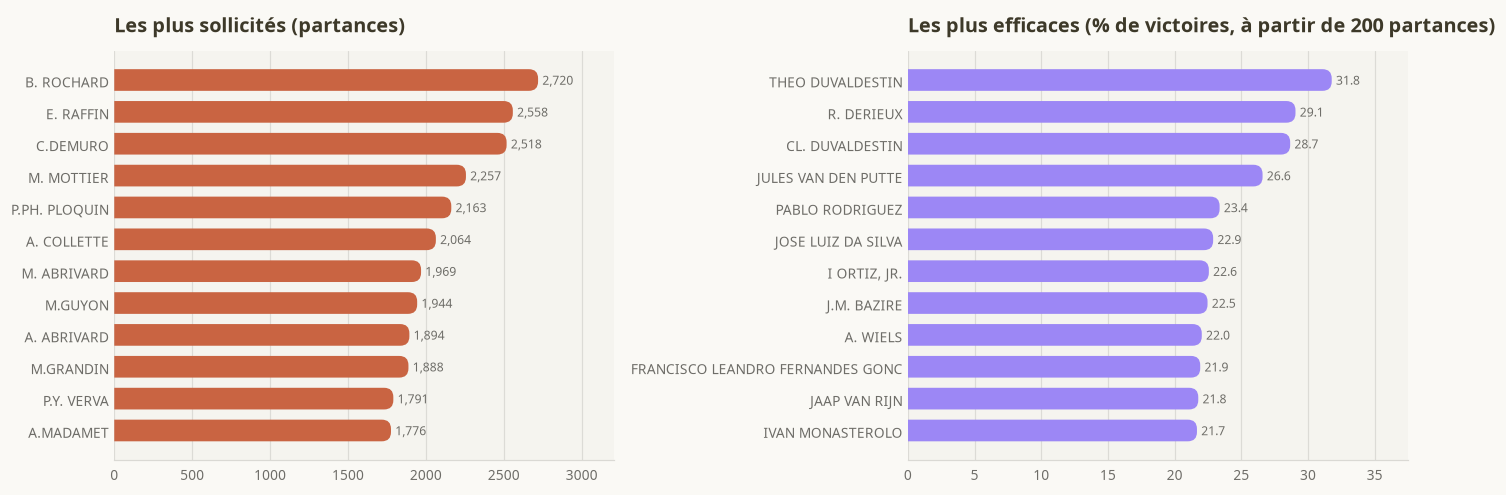

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
barh_ax(axes[0], drivers["participations"].head(12), "Les plus sollicités (partances)")
barh_ax(
    axes[1],
    drivers.sort_values("taux_victoire", ascending=False)["taux_victoire"].head(12),
    "Les plus efficaces (% de victoires, à partir de 200 partances)",
    fmt="{:,.1f}",
    couleur=ds.color_cycle(2)[1],
)
fig.tight_layout()
plt.show()

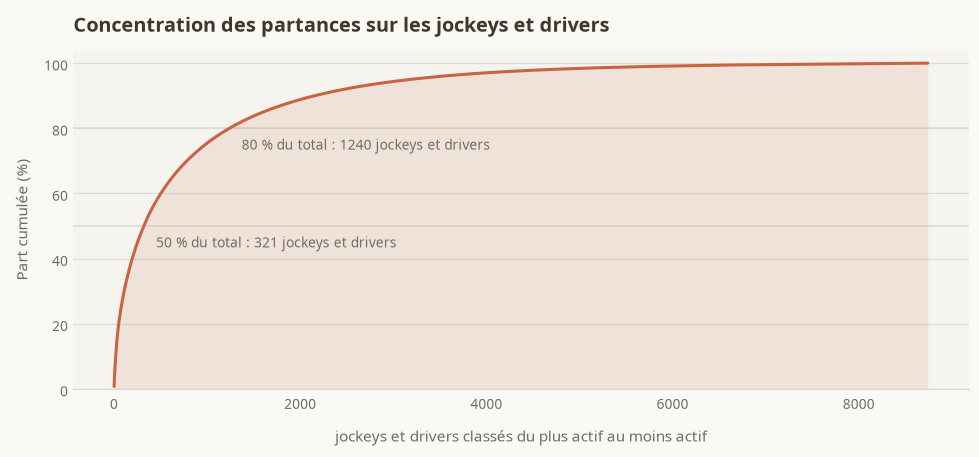

In [41]:
fig, ax = part_cumulee(
    df_participants["driver"].value_counts(),
    "Concentration des partances sur les jockeys et drivers",
    "jockeys et drivers",
)
plt.show()

**À retenir.** Près de 9 000 jockeys et drivers apparaissent dans la base, mais l'activité est très
concentrée : quelques dizaines de professionnels assurent la moitié des partances. Les plus
sollicités montent 2 000 à 2 700 fois sur la période, avec des taux de victoire de 10 à 19 %. Les
noms les plus efficaces sont aussi ceux qui héritent des chevaux les mieux cotés, ce qui invite à
la prudence : ce classement mesure une réussite, pas un talent isolé de son contexte.

### La place au départ compte-t-elle ?

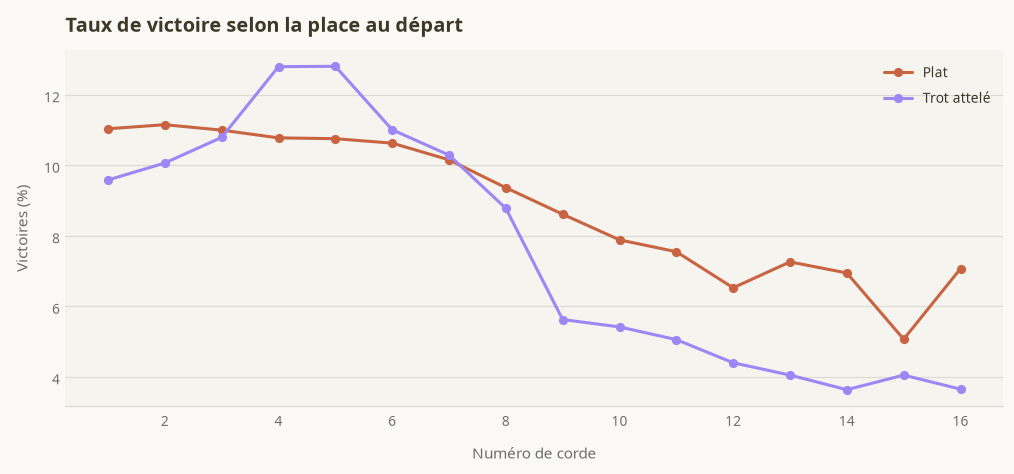

In [42]:
courants_disciplines = courants.merge(
    df_courses[["id", "discipline"]].rename(columns={"id": "course_id"}), on="course_id", how="left"
)
corde = (
    courants_disciplines[
        courants_disciplines["place_corde"].between(1, 16)
        & courants_disciplines["discipline"].isin(["PLAT", "ATTELE"])
    ]
    .groupby(["discipline", "place_corde"], observed=True)["gagnant"]
    .agg(["mean", "size"])
)
fig, ax = figure("Taux de victoire selon la place au départ", (11, 4.2))
for discipline, couleur in zip(["PLAT", "ATTELE"], ds.color_cycle(2)):
    sous_ensemble = corde.loc[discipline]
    sous_ensemble = sous_ensemble[sous_ensemble["size"] >= 200]
    ax.plot(
        sous_ensemble.index,
        sous_ensemble["mean"] * 100,
        marker="o",
        color=couleur,
        label="Plat" if discipline == "PLAT" else "Trot attelé",
    )
ax.set_xlabel("Numéro de corde")
ax.set_ylabel("Victoires (%)")
ax.legend()
plt.show()

**À retenir.** La place au départ est loin d'être neutre : en plat comme au trot attelé, les
premiers numéros gagnent nettement plus souvent que les derniers. L'effet est progressif et
régulier, ce qui en fait une information utile — à condition de se rappeler qu'elle n'est
renseignée que pour 62 % des fiches, les disciplines sans corde n'étant pas concernées.

<a id="rapports"></a>
## 6. Les rapports de paris

Une fois la course courue, le PMU publie ce que chaque pari gagnant a rapporté. La base conserve
ces rapports définitifs, type de pari par type de pari.

In [43]:
from dataset.load_rapports import load_dividendes, load_rapports

df_rapports = load_rapports(start_date, end_date)
simple_gagnant = df_rapports[df_rapports["type_pari"] == "E_SIMPLE_GAGNANT"].copy()
simple_gagnant["dividende_euros"] = simple_gagnant["dividende_premier"] / 100

display(
    chiffres_cles(
        {
            "Rapports enregistrés": nombre(len(df_rapports)),
            "Types de paris distincts": nombre(df_rapports["type_pari"].nunique()),
            "Courses avec au moins un rapport": nombre(df_rapports["course_id"].nunique()),
            "Rapports par course (médiane)": nombre(
                df_rapports.groupby("course_id").size().median()
            ),
            "Gain médian du simple gagnant": nombre(simple_gagnant["dividende_euros"].median(), 2, " € pour 1 €"),
            "Paris remboursés": f"{nombre(df_rapports['rembourse'].mean() * 100, 2)} %",
        },
        "Les rapports en quelques chiffres",
    )
)

,
Rapports enregistrés,195 017
Types de paris distincts,20
Courses avec au moins un rapport,30 845
Rapports par course (médiane),7
Gain médian du simple gagnant,"5,10 € pour 1 €"
Paris remboursés,"0,72 %"


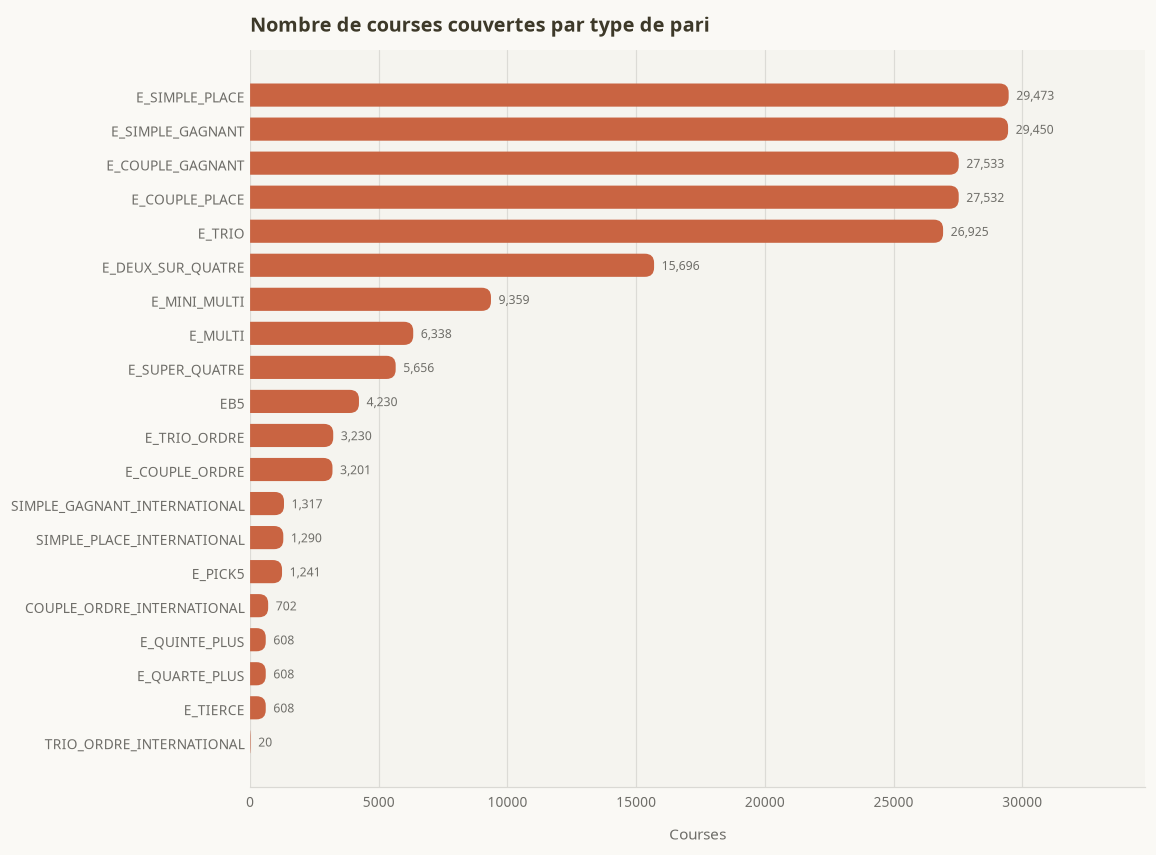

In [44]:
fig, ax = barres(
    df_rapports["type_pari"].value_counts(),
    "Nombre de courses couvertes par type de pari",
    "Courses",
)
plt.show()

In [45]:
familles = (
    df_rapports.groupby("type_pari", observed=True)
    .agg(
        courses=("course_id", "nunique"),
        mise=("mise_base", "median"),
        lignes=("nombre_lignes", "median"),
        gain_median=("dividende_premier", "median"),
    )
    .sort_values("courses", ascending=False)
    .head(12)
)
familles["mise"] = familles["mise"] / 100
familles["gain_median"] = familles["gain_median"] / 100
familles.columns = [
    "Courses couvertes",
    "Mise de base (€)",
    "Rangs récompensés",
    "Gain médian (€)",
]
display(
    tableau(
        familles.rename_axis("Type de pari"),
        "Les douze paris les plus souvent proposés",
        formats={
            "Courses couvertes": lambda v: nombre(v),
            "Mise de base (€)": lambda v: nombre(v, 2),
            "Rangs récompensés": lambda v: nombre(v, 1),
            "Gain médian (€)": lambda v: nombre(v, 2),
        },
        barres=["Courses couvertes"],
    )
)

,Courses couvertes,Mise de base (€),Rangs récompensés,Gain médian (€)
Type de pari,,,,
E_SIMPLE_PLACE,29 473,"1,00","3,0","1,90"
E_SIMPLE_GAGNANT,29 450,"1,00","1,0","5,10"
E_COUPLE_GAGNANT,27 533,"1,00","1,0","19,50"
E_COUPLE_PLACE,27 532,"1,00","3,0","7,20"
E_TRIO,26 925,"1,00","1,0","44,70"
E_DEUX_SUR_QUATRE,15 696,"3,00","6,0","3,80"
E_MINI_MULTI,9 359,"3,00","3,0","51,00"
E_MULTI,6 338,"3,00","4,0","63,00"
E_SUPER_QUATRE,5 656,"1,00","1,0","269,20"


**À retenir.** Vingt formules de paris cohabitent, du simple gagnant au quinté. Les paris simples
et les couplés sont proposés sur presque toutes les courses ; les paris les plus difficiles
(quinté, pick 5, multi) ne concernent qu'une sélection d'épreuves — le quinté, par exemple, une
seule course par journée. Un point de vigilance : **les montants sont stockés en centimes** dans
les rapports, alors que les dotations des courses sont en euros. Les valeurs affichées ici sont
converties.

### Combien rapporte un pari gagnant ?

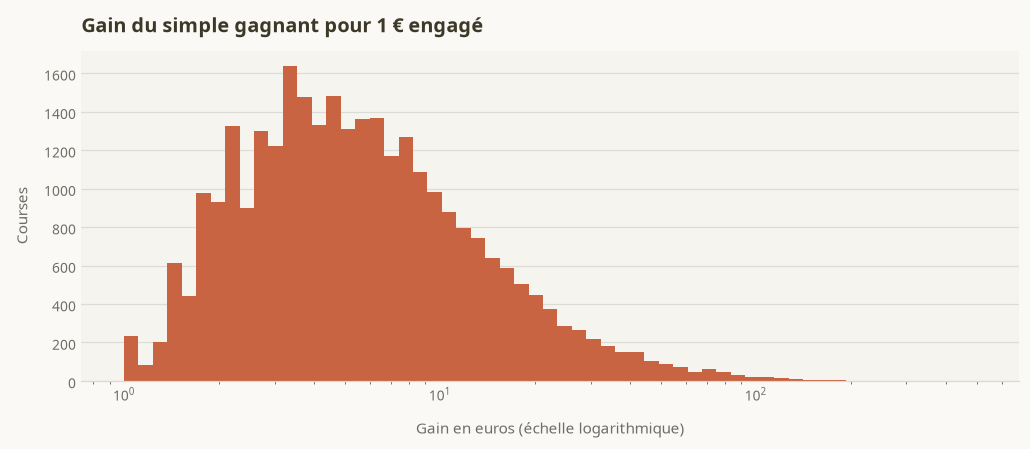

In [46]:
fig, ax = figure("Gain du simple gagnant pour 1 € engagé", (11, 3.9))
ax.hist(
    simple_gagnant.loc[simple_gagnant["dividende_euros"] > 0, "dividende_euros"],
    bins=np.logspace(0, np.log10(500), 60),
    color=THEME["primary"],
)
ax.set_xscale("log")
ax.set_xlabel("Gain en euros (échelle logarithmique)")
ax.set_ylabel("Courses")
plt.show()

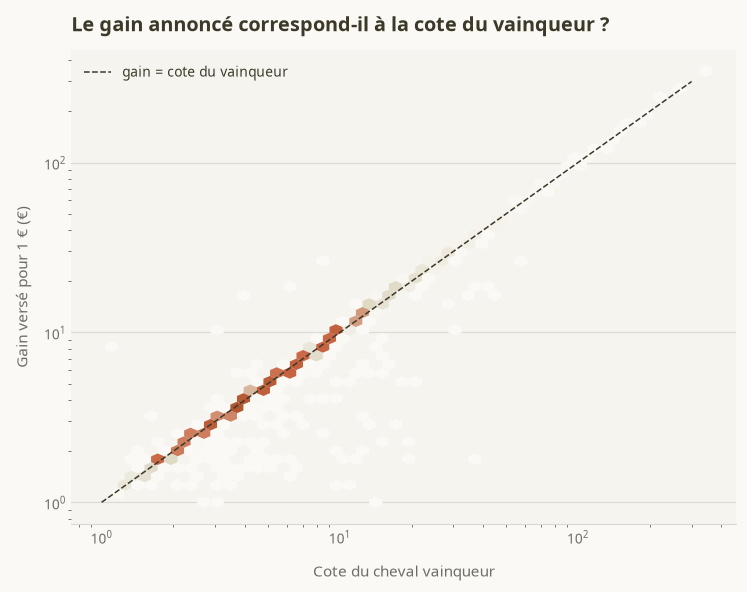

In [47]:
gagnants = courants[courants["gagnant"]][["course_id", "cote_directe"]]
controle = simple_gagnant.merge(gagnants, on="course_id", how="inner")
controle = controle[controle["dividende_euros"].between(1, 500)]

fig, ax = figure("Le gain annoncé correspond-il à la cote du vainqueur ?", (7.8, 5.6))
ax.hexbin(
    controle["cote_directe"],
    controle["dividende_euros"],
    gridsize=45,
    xscale="log",
    yscale="log",
    cmap=ds.sequential_cmap("light"),
    mincnt=1,
    linewidths=0,
)
ax.plot([1, 300], [1, 300], color=THEME["foreground"], linewidth=1, linestyle="--",
        label="gain = cote du vainqueur")
ax.set_xlabel("Cote du cheval vainqueur")
ax.set_ylabel("Gain versé pour 1 € (€)")
ax.legend()
plt.show()

**À retenir.** Le nuage se confond avec la diagonale : le gain versé égale la cote du vainqueur, à
la virgule près (corrélation de 0,999, écart médian nul). C'est la vérification croisée la plus
solide de tout ce document, puisqu'elle met en regard deux informations collectées séparément.
Concrètement, un pari gagnant rapporte le plus souvent autour de 5 € pour 1 € engagé, mais la
queue de distribution monte jusqu'à plus de 300 €.

### Que rapporterait la stratégie la plus simple ?

In [48]:
favoris = (
    courants.sort_values("cote_directe")
    .groupby("course_id", observed=True)
    .first()[["cote_directe", "gagnant"]]
    .rename(columns={"cote_directe": "cote_favori", "gagnant": "favori_gagnant"})
)
strategie = simple_gagnant.set_index("course_id")[["dividende_euros", "date_programme"]].join(
    favoris, how="inner"
)
strategie["gain"] = np.where(strategie["favori_gagnant"], strategie["dividende_euros"], 0.0)

display(
    chiffres_cles(
        {
            "Courses évaluées": nombre(len(strategie)),
            "Cote médiane du favori": nombre(strategie["cote_favori"].median(), 2),
            "Le favori gagne": f"{nombre(strategie['favori_gagnant'].mean() * 100, 1)} % des courses",
            "Retour pour 1 € misé": nombre(strategie["gain"].mean(), 3, " €"),
            "Perte moyenne par euro misé": nombre((1 - strategie["gain"].mean()) * 100, 1, " %"),
        },
        "Miser 1 € sur le favori de chaque course",
    )
)

,
Courses évaluées,29 242
Cote médiane du favori,"2,80"
Le favori gagne,"33,9 % des courses"
Retour pour 1 € misé,"0,882 €"
Perte moyenne par euro misé,"11,8 %"


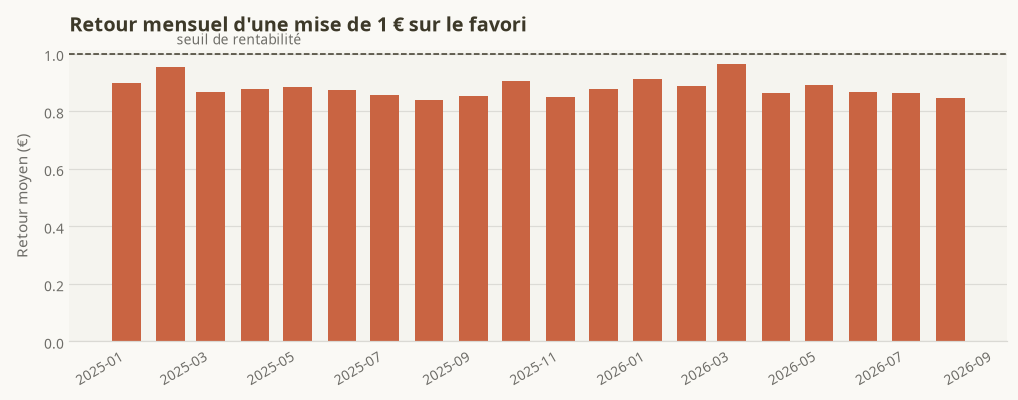

In [49]:
retour_mensuel = strategie.groupby(pd.Grouper(key="date_programme", freq="MS"))["gain"].mean()
fig, ax = figure("Retour mensuel d'une mise de 1 € sur le favori", (11, 3.9))
ax.bar(retour_mensuel.index, retour_mensuel.to_numpy(), width=20, color=THEME["primary"])
ax.axhline(1, color=THEME["foreground"], linewidth=1, linestyle="--")
ax.annotate(
    "seuil de rentabilité",
    xy=(retour_mensuel.index[1], 1),
    xytext=(4, 6),
    textcoords="offset points",
    fontsize=9,
    color=THEME["muted_foreground"],
)
ax.set_ylabel("Retour moyen (€)")
fig.autofmt_xdate()
plt.show()

**À retenir.** Le favori s'impose dans un tiers des courses, pour une cote médiane de 2,80. Miser
systématiquement 1 € sur lui restitue en moyenne 0,88 € : une perte de 12 % par euro engagé, stable
d'un mois sur l'autre. Ce chiffre donne l'étalon à battre pour toute stratégie plus élaborée — et
rappelle qu'aucune approche naïve ne peut être rentable, le prélèvement de l'opérateur étant
prélevé sur chaque enjeu.

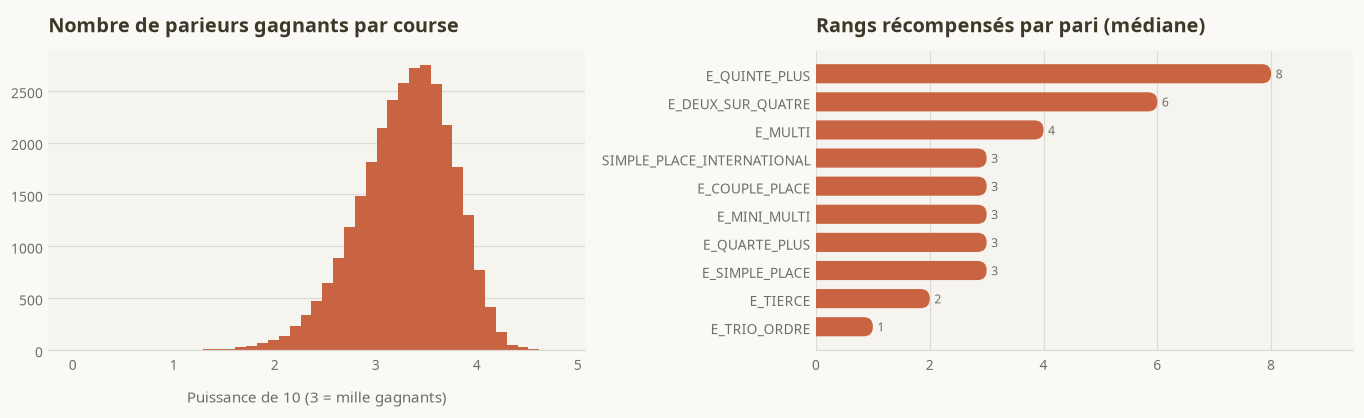

In [50]:
df_dividendes = load_dividendes(start_date, end_date, types_pari=("E_SIMPLE_GAGNANT",))
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.9))
axes[0].hist(
    np.log10(df_dividendes.loc[df_dividendes["nombre_gagnants"] > 0, "nombre_gagnants"]),
    bins=45,
    color=THEME["primary"],
)
axes[0].set_title("Nombre de parieurs gagnants par course")
axes[0].set_xlabel("Puissance de 10 (3 = mille gagnants)")
lignes = df_rapports.groupby("type_pari", observed=True)["nombre_lignes"].median().sort_values()
barh_ax(axes[1], lignes, "Rangs récompensés par pari (médiane)", limite=10)
fig.tight_layout()
plt.show()

**À retenir.** Le nombre de parieurs gagnants varie de quelques dizaines à plusieurs centaines de
milliers selon la notoriété de la course : c'est un bon indicateur indirect de l'engouement du
public. Les paris simples ne récompensent qu'un seul résultat, tandis que les paris de type
« placé » ou « 2 sur 4 » en paient plusieurs, ce qui explique les écarts d'un pari à l'autre.

<a id="limites"></a>
## 7. Ce qui est complet, ce qui ne l'est pas

Cette section est la plus importante pour qui veut exploiter les données : elle dit ce sur quoi on
peut s'appuyer, et ce qu'il faut éviter de supposer.

In [51]:
from dataset.load_couverture_courses import load_couverture_courses

couverture = load_couverture_courses(start_date, end_date).reindex(df_courses["id"]).fillna(0)
couverture.index.name = "course_id"

resume_couverture = pd.DataFrame(
    {
        "Courses concernées": (couverture > 0).sum(),
        "Part des courses (%)": (couverture > 0).mean() * 100,
        "Enregistrements par course (médiane)": couverture.where(couverture > 0).median(),
    }
).rename(index={"participant": "Chevaux engagés", "rapport": "Rapports de paris"})
display(
    tableau(
        resume_couverture,
        "Pour combien de courses dispose-t-on du détail ?",
        formats={
            "Courses concernées": lambda v: nombre(v),
            "Part des courses (%)": lambda v: nombre(v, 1),
            "Enregistrements par course (médiane)": lambda v: nombre(v, 1),
        },
        barres=["Part des courses (%)"],
    )
)

,Courses concernées,Part des courses (%),Enregistrements par course (médiane)
entite,,,
Chevaux engagés,32 553,"100,0","12,0"
Rapports de paris,30 845,"94,8","7,0"


In [52]:
etat_courses = (
    df_courses[["id", "statut"]]
    .set_index("id")
    .join(couverture)
    .groupby("statut", observed=True)
    .agg(
        courses=("participant", "size"),
        sans_rapport=("rapport", lambda serie: (serie == 0).mean() * 100),
    )
    .sort_values("courses", ascending=False)
)
etat_courses.index = etat_courses.index.map(
    {
        "ARRIVEE_DEFINITIVE_COMPLETE": "Arrivée définitive complète",
        "FIN_COURSE": "Course terminée",
        "COURSE_ANNULEE": "Course annulée",
        "PROGRAMMEE": "Course encore programmée",
        "ARRIVEE_DEFINITIVE": "Arrivée définitive",
    }
)
etat_courses.columns = ["Courses", "Sans rapport de paris (%)"]
display(
    tableau(
        etat_courses.rename_axis("État de la course"),
        "L'état des courses enregistrées",
        formats={
            "Courses": lambda v: nombre(v),
            "Sans rapport de paris (%)": lambda v: nombre(v, 1),
        },
        barres=["Courses"],
    )
)

,Courses,Sans rapport de paris (%)
État de la course,,
Arrivée définitive complète,19 686,"7,0"
Course terminée,12 618,"2,3"
Course annulée,222,"1,8"
Course encore programmée,26,"100,0"
Arrivée définitive,1,"0,0"


In [53]:
INFOS_COURSES = {
    "discipline": "Discipline",
    "distance": "Distance",
    "montant_prix": "Dotation",
    "nombre_declares_partants": "Nombre de partants",
    "heure_depart_locale": "Heure de départ",
    "condition_sexe": "Conditions de sexe",
    "corde": "Sens de la corde",
    "duree_course_ms": "Chronomètre de la course",
    "condition_age": "Conditions d'âge",
    "type_piste": "Type de piste",
    "penetrometre_valeur": "Mesure du terrain",
}
INFOS_PARTICIPANTS = {
    "nom": "Nom du cheval",
    "age": "Âge",
    "sexe": "Sexe",
    "driver": "Jockey ou driver",
    "entraineur": "Entraîneur",
    "nombre_courses": "Palmarès (courses, victoires)",
    "gains_carriere": "Gains en carrière",
    "cote_directe": "Cote au départ",
    "cote_reference": "Cote de la veille",
    "ordre_arrivee": "Place à l'arrivée",
    "musique": "Historique de forme",
    "eleveur": "Éleveur",
    "robe": "Robe",
    "place_corde": "Place au départ",
    "reduction_kilometrique": "Record au kilomètre",
    "deferre": "Déferrage",
    "incident": "Incident de course",
}
display(disponibilite(df_courses, INFOS_COURSES, "Informations disponibles sur les courses"))
display(
    disponibilite(
        df_participants, INFOS_PARTICIPANTS, "Informations disponibles sur les chevaux engagés"
    )
)

,Renseigné (%)
Discipline,"100,0 %"
Distance,"100,0 %"
Dotation,"100,0 %"
Nombre de partants,"100,0 %"
Heure de départ,"100,0 %"
Conditions de sexe,"100,0 %"
Chronomètre de la course,"97,6 %"
Sens de la corde,"89,6 %"
Conditions d'âge,"52,4 %"
Type de piste,"43,1 %"


,Renseigné (%)
Nom du cheval,"100,0 %"
Âge,"100,0 %"
Sexe,"100,0 %"
"Palmarès (courses, victoires)","100,0 %"
Jockey ou driver,"100,0 %"
Entraîneur,"100,0 %"
Gains en carrière,"97,3 %"
Historique de forme,"96,1 %"
Cote au départ,"91,9 %"
Éleveur,"88,2 %"


### Contrôles de cohérence

In [54]:
programmes_raw = pd.json_normalize(
    df_programmes["raw"].dropna().map(lambda raw: raw["programme"]).tolist()
)
date_annoncee = pd.to_datetime(
    programmes_raw["date"] + programmes_raw["timezoneOffset"], unit="ms"
).dt.date
coherence_dates = (date_annoncee.to_numpy() == df_programmes["date_programme"].dt.date.to_numpy()).mean()

effectifs = pd.DataFrame(
    {
        "declares": df_courses.set_index("id")["nombre_declares_partants"],
        "enregistres": df_participants.groupby("course_id").size(),
    }
).dropna()
correlation_cote = controle["cote_directe"].corr(controle["dividende_euros"])
ecart_dividende = (
    (controle["dividende_euros"] - controle["cote_directe"]) / controle["cote_directe"]
).median()

controles = pd.DataFrame(
    {
        "Résultat": [
            f"{nombre(coherence_dates * 100, 1)} %",
            f"{nombre((effectifs['enregistres'] == effectifs['declares']).mean() * 100, 1)} %",
            f"{nombre(correlation_cote, 3)}",
            f"{nombre(ecart_dividende * 100, 2)} %",
            f"{nombre(df_courses['vitesse_kmh'].between(30, 70).mean() * 100, 1)} %",
        ]
    },
    index=[
        "La date annoncée par le PMU correspond au jour enregistré",
        "Le nombre de partants annoncé correspond aux fiches enregistrées",
        "Corrélation entre le gain versé et la cote du vainqueur",
        "Écart médian entre le gain versé et la cote du vainqueur",
        "Vitesses moyennes dans une plage plausible (30 à 70 km/h)",
    ],
)
display(tableau(controles, "Cinq vérifications croisées", formats={"Résultat": "{}"}))

,Résultat
La date annoncée par le PMU correspond au jour enregistré,"99,8 %"
Le nombre de partants annoncé correspond aux fiches enregistrées,"100,0 %"
Corrélation entre le gain versé et la cote du vainqueur,"0,999"
Écart médian entre le gain versé et la cote du vainqueur,"0,00 %"
Vitesses moyennes dans une plage plausible (30 à 70 km/h),"97,4 %"


### Synthèse des anomalies

In [55]:
anomalies = pd.DataFrame(
    [
        ("Journées absentes du calendrier", len(journees_manquantes), len(jours_attendus)),
        ("Réunions sans météo", int(reunions["meteo.temperature"].isna().sum()), len(reunions)),
        ("Réunions sans région hippique", int(reunions["regionHippique"].isna().sum()), len(reunions)),
        ("Courses annulées", int((df_courses["statut"] == "COURSE_ANNULEE").sum()), len(df_courses)),
        ("Courses encore programmées", int((df_courses["statut"] == "PROGRAMMEE").sum()), len(df_courses)),
        ("Courses sans chronomètre exploitable", int((df_courses["duree_course_ms"].fillna(0) <= 0).sum()), len(df_courses)),
        ("Courses à la dotation en devise étrangère", int((df_courses["montant_prix"] > 1_000_000).sum()), len(df_courses)),
        ("Courses sans rapport de paris", int((couverture["rapport"] == 0).sum()), len(df_courses)),
        ("Chevaux déclarés puis non partants", int((df_participants["statut"] == "NON_PARTANT").sum()), len(df_participants)),
        ("Chevaux sans place à l'arrivée", int(df_participants["ordre_arrivee"].isna().sum()), len(df_participants)),
        ("Cotes à la valeur de remplissage 999", int((df_participants["cote_directe"] == 999).sum()), len(df_participants)),
        ("Paris remboursés", int(df_rapports["rembourse"].sum()), len(df_rapports)),
    ],
    columns=["Anomalie", "Occurrences", "Population"],
).set_index("Anomalie")
anomalies["Part de la population (%)"] = anomalies["Occurrences"] / anomalies["Population"] * 100
anomalies = anomalies.drop(columns="Population").sort_values("Part de la population (%)", ascending=False)
display(
    tableau(
        anomalies,
        "Les zones d'attention, de la plus étendue à la plus marginale",
        formats={
            "Occurrences": lambda v: nombre(v),
            "Part de la population (%)": lambda v: nombre(v, 2),
        },
        barres=["Part de la population (%)"],
    )
)

,Occurrences,Part de la population (%)
Anomalie,,
Réunions sans région hippique,3 821,"80,44"
Chevaux sans place à l'arrivée,63 519,"16,97"
Courses sans rapport de paris,1 708,"5,25"
Chevaux déclarés puis non partants,14 175,"3,79"
Réunions sans météo,136,"2,86"
Courses sans chronomètre exploitable,787,"2,42"
Paris remboursés,1 398,"0,72"
Courses annulées,222,"0,68"
Cotes à la valeur de remplissage 999,1 392,"0,37"


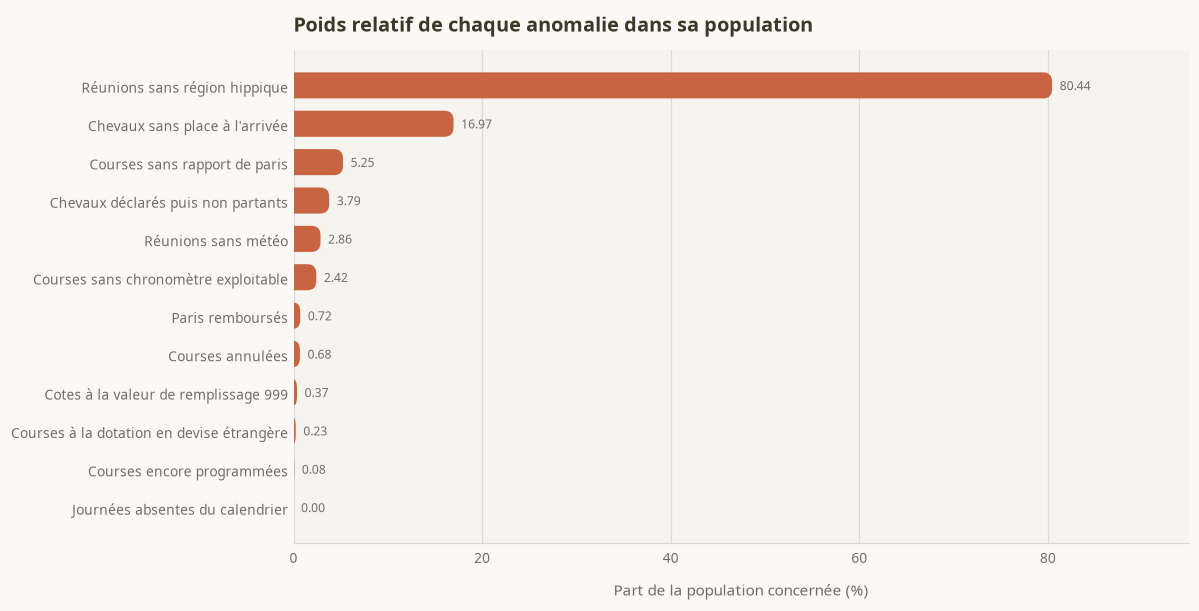

In [56]:
fig, ax = barres(
    anomalies["Part de la population (%)"],
    "Poids relatif de chaque anomalie dans sa population",
    "Part de la population concernée (%)",
    fmt="{:,.2f}",
)
plt.show()

**À retenir.** Trois constats se dégagent.

*Ce sur quoi on peut s'appuyer sans réserve.* Le calendrier est complet, chaque course dispose de
la fiche de tous ses partants, et les informations structurantes — discipline, distance, dotation,
nombre de partants, heure de départ, identité du cheval, du jockey et de l'entraîneur — sont
renseignées à 100 %.

*Ce qui demande une précaution.* La place à l'arrivée manque pour 17 % des fiches, mais ce n'est
pas un défaut de collecte : ce sont les chevaux non partants, disqualifiés ou tombés. De même, les
informations propres à une discipline (record au kilomètre pour le trot, place à la corde et type
de piste pour le galop) ne sont logiquement présentes que sur le périmètre concerné. Les dotations
des courses étrangères, exprimées en devise locale, ne doivent pas être mélangées aux dotations
françaises.

*Ce qui est réellement absent.* Environ 5 % des courses n'ont pas de rapport de paris : il s'agit
pour l'essentiel de courses annulées ou d'épreuves étrangères non ouvertes aux paris français. La
cote conservée est celle du départ, et non son évolution au fil des enjeux.

<a id="bilan"></a>
## 8. Le mot de la fin

In [57]:
bilan = {
    "Période couverte": f"{debut:%d/%m/%Y} → {fin:%d/%m/%Y} ({nombre(len(jours_attendus))} journées)",
    "Réunions": nombre(len(reunions)),
    "Courses": nombre(len(df_courses)),
    "Chevaux engagés": nombre(len(df_participants)),
    "Rapports de paris": nombre(len(df_rapports)),
    "Hippodromes": nombre(reunions["hippodrome.libelleLong"].nunique()),
    "Pays": nombre(reunions["pays.code"].nunique()),
    "Chevaux différents": nombre(df_participants["nom"].nunique()),
    "Jockeys et drivers": nombre(df_participants["driver"].nunique()),
    "Courses par journée": nombre(volumes["course"].where(volumes["course"] > 0).mean(), 1),
    "Chevaux par course": nombre(len(partants) / len(df_courses), 1),
    "Le favori gagne": f"{nombre(strategie['favori_gagnant'].mean() * 100, 1)} % des courses",
    "Retour d'une mise sur le favori": nombre(strategie["gain"].mean(), 3, " € pour 1 € misé"),
}
display(chiffres_cles(bilan, "La base en un tableau"))

,
Période couverte,01/01/2025 → 31/08/2026 (608 journées)
Réunions,4 750
Courses,32 553
Chevaux engagés,374 351
Rapports de paris,195 017
Hippodromes,253
Pays,30
Chevaux différents,71 887
Jockeys et drivers,8 742
Courses par journée,"53,5"


En vingt mois, la base a rassemblé une photographie complète et cohérente du programme hippique :
chaque journée, chaque réunion, chaque course et chaque cheval engagé y figurent, avec le résultat
et ce que les paris ont rapporté. Les vérifications croisées — cotes contre résultats, gains contre
cotes, distances contre chronomètres — concordent toutes, ce qui donne confiance dans l'ensemble.

Ce matériau se prête déjà à de nombreuses lectures : comparer les hippodromes, suivre la forme d'un
cheval ou d'un jockey, mesurer l'effet de la place au départ, ou estimer ce que rapporte une
stratégie de pari. Deux limites doivent rester en tête : les montants des courses étrangères sont
exprimés dans leur devise d'origine, et certaines informations ne concernent qu'une discipline —
le record au kilomètre pour le trot, la place à la corde pour le galop.